# **Three LM architectures — three spaces**
The encoder you pick is the space you get: how embedding geometry follows from the attention mask

When we design an experiment, we try different architectures. In applied work we care about the output and the side characteristics (speed, framework support, how recent the model is); in research work we are usually after an interesting result.

How do we avoid finding that result where there is none, when we compare models of different architectures? What is true of an architecture simply by its definition? Those lovely questions are what this article is about.

> Hi, reader! My name is Sabrina, and this is one more tutorial from my series about looking inside models. I am writing this in a place where a lot of people go hiking. And like any good hike, this article comes with several viewpoints! : )

**What is ahead:**

1. **The theory of three masks** — one attention formula, three ways to mask it.
2. **Token informativeness** — which positions saw what, and how much they weigh.
3. **Geometry** (the main part) — anisotropy, spectrum, participation ratio, CKA.
4. **Takeaways** — what all of this is good for in practice.
5. **Cheat sheet and pitfalls** — what not to do and where to look.

Four models, all tiny, everything runs on CPU in a few minutes and, as always, lives in a notebook. Grab water, coffee, snacks — and off we go!

## **The architectures we look at**

Language model architectures are usually split into three families: encoder-only, decoder-only and encoder-decoder. On diagrams (and in memes) they look different and they solve different tasks, but on the inside they are, generally speaking, built very much alike.


## **What they share: attention**
In every family the core computation is attention, with the same familiar formula:

$$\text{Attn}(Q, K, V) = \operatorname{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right) V$$

Here $Q = XW_Q$, $K = XW_K$, $V = XW_V$ are linear projections of the input, and $M$ is the **additive mask**: a matrix of zeros and $-\infty$. Zero means "you may look", $-\infty$ turns into a zero weight after the softmax and means "you may not".

### **Footnote: if the formula is unfamiliar or has faded**

Take the classic example: the sentence «the cat sat» comes in, and every token has already been turned into a vector $x_1, x_2, x_3$. The attention layer gives each vector three roles:

- $q_i = x_i W_Q$ — the **query**: "what am I looking for in the context";
- $k_i = x_i W_K$ — the **key**: "by which feature can I be found";
- $v_i = x_i W_V$ — the **value**: "what I hand over to whoever found me".

**Step 1. Compatibility.** The dot product of every query with every key: $s_{ij} = \langle q_i, k_j \rangle$. That gives an $n \times n$ matrix — "how interested token $i$ is in token $j$".

**Step 2. Scale.** Divide by $\sqrt{d_k}$. Without it, large $d_k$ makes the dot products grow, the softmax saturates (one weight ≈ 1, the rest ≈ 0), and the gradients die.

**Step 3. Mask.** Add $M$. A zero changes nothing; $-\infty$ guarantees a zero weight after the exponent, because $e^{-\infty} = 0$.

**Step 4. Row-wise softmax.** Every row becomes a distribution: the weights are non-negative and sum to one. The key words are **row-wise**: token $i$ splits its own unit of attention among all the $j$ available to it.

**Step 5. Weighted sum.** $h_i = \sum_j a_{ij} v_j$ — the new representation of a token is a blend of the values of everyone it looked at, weighted by step 4.

After that the whole thing runs $H$ times in parallel (multi-head), the results are concatenated and pass through one more linear projection, with a residual connection, normalisation and an MLP around it all. The effects we will exploit in this tutorial live in steps 3–5.

### 
Note that:

1. **A softmax row must sum to one.** A head cannot "look nowhere": if it needs nothing at this step, the attention mass still has to go somewhere.
2. **The mask sits inside the softmax, not after it.** Forbidding "looking ahead" is not zeroing weights after the fact, it is a redistribution: the remaining weights are renormalised.

Generalising, what changes between the families is mostly which tokens are allowed to see which other tokens, and where the context for attention comes from. In other words, geometrically we reduce (crudely, but we are entitled to) the architectural differences to two things:
- the attention mask
- the source of (Q, K, V)

| Architecture | $M_{ij}$ | Source of $Q$ | Source of $K, V$ |
|---|---|---|---|
| **encoder-only** (BERT) | $0$ everywhere | the layer itself | the layer itself |
| **decoder-only** (GPT-2) | $0$ for $j \le i$; $-\infty$ for $j > i$ | the layer itself | the layer itself |
| **enc-dec: encoder** (T5, BART) | $0$ everywhere | encoder | encoder |
| **enc-dec: decoder self-attn** | triangular | decoder | decoder |
| **enc-dec: cross-attention** | $0$ everywhere | **decoder** | **encoder** |

> Thanks to LLMs for the tables one learns to make in order to present information compactly.

Three facts we care about follow from this table:

**Fact 1. Who saw what.** In a causal model (decoder) the representation of the token at position $i$ is a function of the prefix $x_{\le i}$ *only*. Formally:

$$h_i^{\text{causal}} = f(x_1, \dots, x_i), \qquad h_i^{\text{bidir}} = f(x_1, \dots, x_n)$$

By construction, then: tokens inside **one** sequence carry **different amounts of context**: the first one saw a single word, the last one saw the whole sentence.

**Fact 2. Where "the meaning of the whole" lives.** In encoder-only it is smeared over all positions (plus `[CLS]`, which *was* trained to aggregate — but trained for Next Sentence Prediction). In decoder-only it sits strictly in the last token, the only one that saw everything. In encoder-decoder it is in the encoder output; the decoder state is no longer "the meaning of the input" but "the state of generation".

**Fact 3. How many spaces.** One, one and **two**. In an encoder-decoder the encoder space and the decoder space were trained for different roles: different norms, different bases, different meaning of the coordinates.

Each fact brings its own geometric subtleties and troubles. Those are what we are going to look at.

### **What differs: the objective**

Fine, we have the mask, but that is only half of what we need. Models are also trained on genuinely different tasks:

- **MLM** (BERT, encoder): mask random tokens and restore them from **two-sided** context. Every position has to be self-sufficient — a specific word must be recoverable from it. That pressure "smears" information over all positions and over many directions.

- **CLM** (GPT-2, decoder): predict the next token. Essentially **one** function is optimised — the distribution over the vocabulary at the output. The space collapses along directions useful for next-token prediction; whatever is not needed for that gets squeezed. As we will see, the collapse is quite literal.

- **Span corruption** (T5, encoder-decoder) and **denoising / text infilling** (BART, encoder-decoder): corrupt the text — drop chunks — and restore it in full. The encoder is bidirectional, but its output has to be convenient for the decoder to **consume** through cross-attention. That is a third, separate pressure on geometry, and T5 and BART implement it differently.

### **A reminder of the training objectives**

- **MLM** (BERT) — random 15% of the tokens, two-sided context (of those, 80% are replaced by `[MASK]`, 10% by a random token, 10% are left as is).

Example: `The doctor told the [MASK] that the surgery was successful.` — `patient`.

- **NSP** (BERT) — the task of telling whether two chunks of text follow one another.

Example: `[CLS] The doctor told the patient … [SEP] The surgery took three hours. [SEP]` — `IsNext`

- **CLM** (GPT-2) — predicting the next token from the left context.

Example: `The doctor told the` → `patient`.

- **Span corruption** (T5) — training on dropped spans, each hidden behind its own sentinel token.

Example: input `The doctor told the <X> that the surgery <Y> successful.` — target `<X> patient <Y> was <Z>`

- **Denoising / text infilling** (BART) — the task of restoring the whole text after arbitrary corruption: spans collapse into a single `<mask>`, sentences get permuted, tokens get deleted.

Example: `The doctor <mask> the surgery was successful.` — the full original

Later all of this was of course revised (ELECTRA, DeBERTa, ALBERT already carry corrections of varying strength), but the basis is still this.

###
Let us keep in mind that MLM requires **every** position to be self-sufficient — a specific word is restored from it. CLM optimises **one** position for a single distribution over the vocabulary. Span corruption and denoising make the encoder output convenient not for a classifier but **for the decoder to read** through cross-attention. Those are, generally speaking, three different pressures on geometry.

`[CLS]` deserves a separate note: it is the only position in BERT that was explicitly taught to aggregate — but taught under NSP, that is, under "do these two chunks follow one another", and that is mostly solved by a topic match.

## **Ready for the practice**

So, from the paragraphs above we saw that **the mask decides which token looks where, and the objective pushes on the shape the token cloud can take**. Three facts from the definition of the mask, three tasks behind the families — and we still have not verified anything. Let us rub our hands in anticipation and get to the experiment.

## **Setup**

The notebook was written on a Mac (MPS) and tested on CPU. All models are small; a full run takes a few minutes.

Data: **English Web Treebank** — real sentences for the qualitative experiments, and **ag_news** — texts for the token clouds and for CKA.

In [1]:
# ── Setup: every import of the notebook lives here ──────────────────
import warnings
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
from transformers import AutoModel, AutoTokenizer, T5EncoderModel

warnings.filterwarnings("ignore")
import transformers

transformers.logging.set_verbosity_error()

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
plt.rcParams.update({"font.size": 10, "figure.dpi": 110})


MARKERS = ["o", "s", "^", "D", "v", "P"]
CAUSAL_STACKS = {"GPT-2 (dec-only)", "T5-dec (enc-dec)", "BART-dec (enc-dec)"}


def style(label):
    """Dashed line for a causal type, solid for a bidirectional one."""
    return "--" if label in CAUSAL_STACKS else "-"

print("torch:", torch.__version__, "| transformers:", transformers.__version__)

torch: 2.8.0 | transformers: 5.10.2


### **Data**

English Web Treebank — English texts from the web (blogs, reviews, emails, forums) with syntactic annotation made by humans. We take sentences for the experiments from it.

In [2]:
import random
from datasets import load_dataset

UD_NAME, UD_CONFIG = "universal-dependencies/universal_dependencies", "en_ewt"


def load_ud(split="train"):
    return load_dataset(UD_NAME, UD_CONFIG, split=split)


def causal_test_sentence(ud, target_chars=70):
    """One sentence for the influence matrix.

    The choice is deterministic — we take the one closest in length to
    target_chars, so the picture does not change from run to run.
    """
    candidates = [t for t in ud["text"] if 40 <= len(t) <= 110 and t.count(" ") >= 8]
    return min(candidates, key=lambda t: abs(len(t) - target_chars))


UD = load_ud()

CAUSAL_TEST_SENTENCE = causal_test_sentence(UD)

print(f"Sentences in the corpus: {len(UD)}")
print(f"\nExample:\n  {CAUSAL_TEST_SENTENCE!r}")


Sentences in the corpus: 12544

Example:
  'You wonder if he was manipulating the market with his bombing targets.'


### **Models**

| Family | Model | Layers | $D$ | Attention | Objective |
|---|---|---|---|---|---|
| encoder-only | `bert-base-uncased` | 12 | 768 | bidirectional | MLM + NSP |
| decoder-only | `gpt2` | 12 | 768 | causal | CLM |
| encoder-decoder | `facebook/bart-base` | 6 + 6 | 768 | enc: bidir. / dec: causal + cross | denoising (text infilling) |
| encoder-decoder | `t5-small` | 6 + 6 | 512 | enc: bidir. / dec: causal + cross | span corruption |

That is the list of models we will analyse. It is put together so as to:
- cover all three families at comparable dimensionality and with a comparable number of heads (the first three);
- keep control over the other free parameters inside encoder-decoder (T5: RMSNorm without a shift, relative position bias, span corruption; BART: ordinary LayerNorm, learned absolute positions, a denoising objective).

A fair question: inside encoder-decoder there is a control (two models), but where is the control for encoder-only and for decoder-only? We will cheat and pull both out of the same list:

- **The control for encoder-only is the T5 and BART encoders.** That gives us three bidirectional models: BERT, the T5 encoder, the BART encoder.

- **The control for decoder-only is the T5 and BART decoders.** That gives us three causal models as well: GPT-2, the T5 decoder, the BART decoder.

They differ in dimensionality, depth, objective, tokenizer and pretraining corpus — that is, they provide enough variability.


> **A technical note.** In `transformers` 5.x the SDPA attention implementation is the default, and with it `output_attentions=True` returns an **empty list** (a bug). Any analysis of attention needs `attn_implementation="eager"`.

In [3]:
# ── Six types: encoder-only, decoder-only and BOTH halves of two encoder-decoders ──
MODEL_IDS = {                      # encoder-side parts: the «text embedding» lives here
    "BERT (enc-only)": "bert-base-uncased",
    "GPT-2 (dec-only)": "gpt2",
    "T5-enc (enc-dec)": "t5-small",
    "BART-enc (enc-dec)": "facebook/bart-base",
}
S2S_IDS = {                        # decoder-side parts of the same two encoder-decoders
    "T5-dec (enc-dec)": "t5-small",
    "BART-dec (enc-dec)": "facebook/bart-base",
}
ALL_LABELS = list(MODEL_IDS) + list(S2S_IDS)


def shift_right(ids, model):
    """Teacher forcing: the decoder reads the same text, shifted by one."""
    out = ids.new_zeros(ids.shape)
    out[:, 1:] = ids[:, :-1].clone()
    out[:, 0] = model.config.decoder_start_token_id
    return out


class DecoderStack:
    """A decoder with the interface of an ordinary encoder model.

    Calling it runs the full seq2seq model — a decoder does not exist
    without its encoder — and returns the decoder side of the output.
    Everything downstream (influence matrices, saturation, clouds, CKA)
    therefore works with a decoder without a single change.
    """

    def __init__(self, model):
        self.model = model
        self.config = model.config

    def parameters(self):
        return self.model.get_decoder().parameters()

    def __call__(self, input_ids, attention_mask=None,
                 output_hidden_states=False, output_attentions=False):
        with torch.no_grad():
            out = self.model(
                input_ids=input_ids, attention_mask=attention_mask,
                decoder_input_ids=shift_right(input_ids, self.model),
                output_hidden_states=output_hidden_states,
                output_attentions=output_attentions,
            )
        return SimpleNamespace(
            last_hidden_state=out.last_hidden_state,          # decoder side
            hidden_states=out.decoder_hidden_states,
            attentions=out.decoder_attentions,                # decoder self-attention
            cross_attentions=out.cross_attentions,
            encoder_last_hidden_state=out.encoder_last_hidden_state,
            encoder_attentions=out.encoder_attentions,
        )


TOK, MODEL, S2S = {}, {}, {}

for label, mid in MODEL_IDS.items():
    tok = AutoTokenizer.from_pretrained(mid)
    if tok.pad_token is None:      # GPT-2 ships without a pad token
        tok.pad_token = tok.eos_token
    TOK[label] = tok
    # For both encoder-decoders we take the encoder alone: it is the part
    # that produces the «text embedding».
    # eager attention: under SDPA output_attentions returns an empty list
    # (see the note above), while the numbers themselves are unaffected.
    if mid.startswith("t5"):
        model = T5EncoderModel.from_pretrained(mid, attn_implementation="eager")
    elif "bart" in mid:
        model = AutoModel.from_pretrained(mid, attn_implementation="eager").encoder
    else:
        model = AutoModel.from_pretrained(mid, attn_implementation="eager")
    MODEL[label] = model.eval()

for label, mid in S2S_IDS.items():
    S2S[label] = AutoModel.from_pretrained(mid, attn_implementation="eager").eval()
    MODEL[label] = DecoderStack(S2S[label])
    TOK[label] = AutoTokenizer.from_pretrained(mid)


def _cfg(cfg, *names):
    for n in names:
        if getattr(cfg, n, None) is not None:
            return getattr(cfg, n)
    return None


def _first_token(label):
    """What actually sits at position 0: a service token or an ordinary word."""
    if label in S2S_IDS:
        return TOK[label].convert_ids_to_tokens([S2S[label].config.decoder_start_token_id])[0]
    ids = TOK[label](CAUSAL_TEST_SENTENCE, return_tensors="pt")["input_ids"]
    return TOK[label].convert_ids_to_tokens(ids[0][:1])[0]


rows = []
for label in ALL_LABELS:
    cfg, is_dec = MODEL[label].config, label in S2S_IDS
    rows.append([
        label, (S2S_IDS if is_dec else MODEL_IDS)[label],
        _cfg(cfg, "decoder_layers", "num_decoder_layers") if is_dec
        else _cfg(cfg, "num_hidden_layers", "n_layer", "num_layers", "encoder_layers"),
        _cfg(cfg, "hidden_size", "n_embd", "d_model"),
        _cfg(cfg, "decoder_attention_heads", "num_heads") if is_dec
        else _cfg(cfg, "num_attention_heads", "n_head", "num_heads", "encoder_attention_heads"),
        f"{sum(p.numel() for p in MODEL[label].parameters()) / 1e6:.0f}M",
        len(TOK[label]),
        _first_token(label),
    ])

print(
    pd.DataFrame(
        rows,
        columns=["Type", "Model", "Layers", "D", "Heads", "Params (the part we take)",
                 "Vocab", "What sits at position 0"],
    ).to_string(index=False)
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/51 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

              Type              Model  Layers   D  Heads Params (the part we take)  Vocab What sits at position 0
   BERT (enc-only)  bert-base-uncased      12 768     12                      109M  30522                   [CLS]
  GPT-2 (dec-only)               gpt2      12 768     12                      124M  50257                     You
  T5-enc (enc-dec)           t5-small       6 512      8                       35M  32100                    ▁You
BART-enc (enc-dec) facebook/bart-base       6 768     12                       82M  50265                     <s>
  T5-dec (enc-dec)           t5-small       6 512      8                       42M  32100                   <pad>
BART-dec (enc-dec) facebook/bart-base       6 768     12                       96M  50265                    </s>


> The "Parameters" column counts only the part we actually analyse: for T5 and BART that is the **encoder**, not the whole seq2seq model. That is why the numbers are smaller than the ones on the model cards.

We are not going to resist the temptation to poke the decoders — but a decoder does not start as easily as an encoder. An encoder needs one input: feed the text, take the states. A decoder needs two at once — what the encoder read (that arrives through cross-attention) and `decoder_input_ids`, that is, "what has already been generated". Without the second one the forward pass simply does not compute.

> The intuition "the encoder squeezed the text into one vector and the decoder took it" comes from RNN seq2seq. In a transformer there is no single vector: the decoder reads **all** the encoder output vectors through cross-attention, anew at every one of its layers and at every generation step, while also looking at what it has already written itself.

So a state "for text X" does not exist for a decoder — there is a state "for the pair (input X, history Y)", and the history is ours to choose. We take the most transparent option, teacher forcing: the same text shifted one position to the right.

Technically we wrap the decoder into an object with the same interface as an ordinary model: you call it and get `last_hidden_state`, `hidden_states`, `attentions`. After that the rest of the notebook simply works with the decoder parts as well.

## **Part 1. Checking the mask**

Since we claimed that attention is shared but different, let us show it — we will check attention by **intervention** (that is, by interfering).

How:
Take a sentence. Corrupt the token at position $j$ (replace it with `[UNK]`). Look at how much the hidden state changed at **every** position $i$:

$$\text{Influence}[i, j] = \bigl\| h_i(x) - h_i(x_{j \to \text{UNK}}) \bigr\|_2$$

That is an $n \times n$ matrix. What we expect:

- when the model is **bidirectional**, corrupting any token changes everything;
- when the model is **causal**, corrupting token $j$ physically cannot affect positions $i < j$ (they depend on the past, and the past did not change), so the upper triangle must be **zero**.

In [4]:
# ── Mask test: corrupt token j, measure the change at every position i ──
def influence_matrix(model, tok, sentence):
    """An (n, n) matrix: influence[i, j] = ||h_i(original) - h_i(token j corrupted)||."""
    enc = tok(sentence, return_tensors="pt")
    ids = enc["input_ids"]
    n = ids.shape[1]

    with torch.no_grad():
        base = model(**enc, output_hidden_states=True).hidden_states[-1][0]

    unk = tok.unk_token_id if tok.unk_token_id is not None else tok.eos_token_id
    M = np.zeros((n, n))
    for j in range(n):
        corrupted = ids.clone()
        corrupted[0, j] = unk
        enc_j = {k: (corrupted if k == "input_ids" else v) for k, v in enc.items()}
        with torch.no_grad():
            h = model(**enc_j, output_hidden_states=True).hidden_states[-1][0]
        M[:, j] = (h - base).norm(dim=-1).numpy()

    return M, tok.convert_ids_to_tokens(ids[0])


INFLUENCE = {}
for label in MODEL_IDS:
    M, toks = influence_matrix(MODEL[label], TOK[label], CAUSAL_TEST_SENTENCE)
    INFLUENCE[label] = (M, toks)
    n = M.shape[0]
    denom = n * (n - 1) / 2
    future = np.triu(M, 1).sum() / denom  # j > i : influence of the future
    past = np.tril(M, -1).sum() / denom   # j < i : influence of the past
    print(f"{label:18s} mean |Δh| from the future = {future:8.4f} | from the past = {past:8.4f}")

BERT (enc-only)    mean |Δh| from the future =   5.7298 | from the past =   4.3736


GPT-2 (dec-only)   mean |Δh| from the future =   0.0000 | from the past =  40.7667
T5-enc (enc-dec)   mean |Δh| from the future =   0.9694 | from the past =   0.7509


BART-enc (enc-dec) mean |Δh| from the future =   1.2794 | from the past =   1.3181


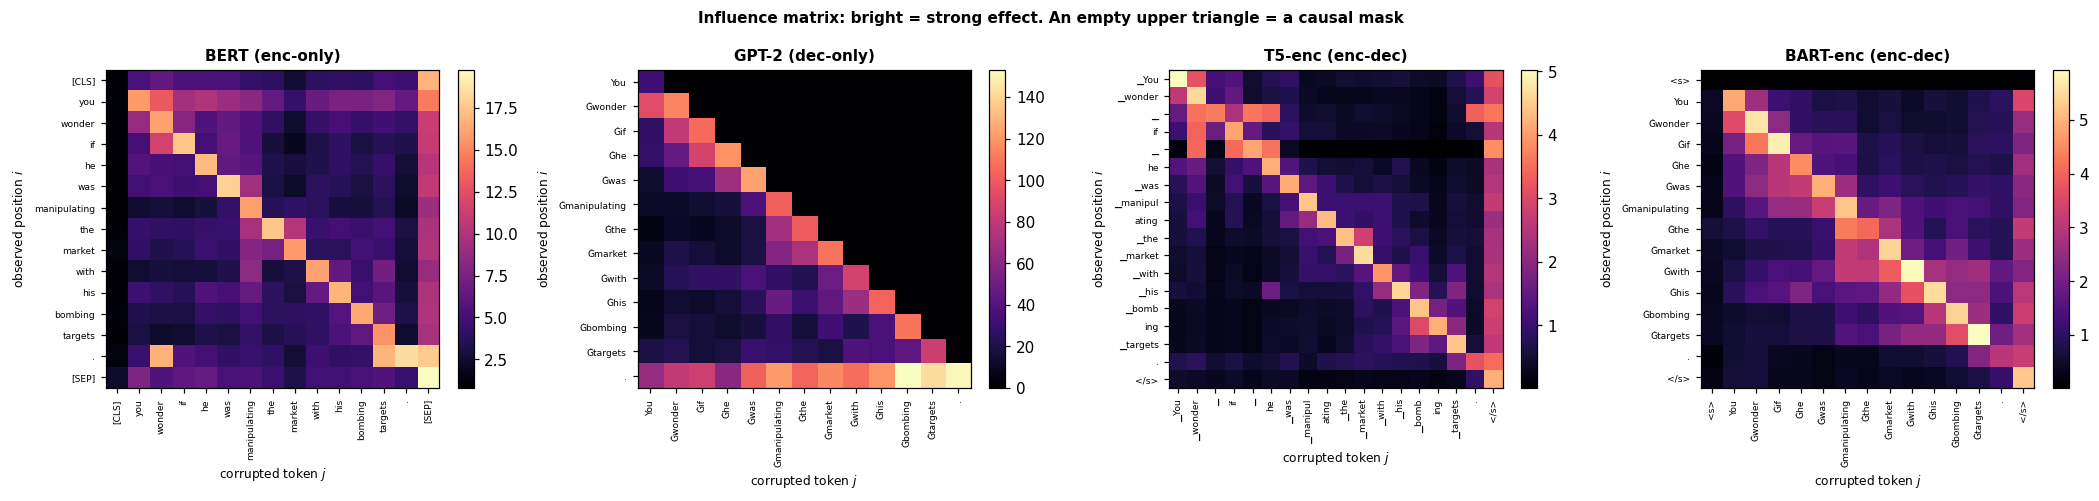

In [5]:
# ── Influence heatmaps ───────────────────────────────────────────────
fig, axes = plt.subplots(1, len(MODEL_IDS), figsize=(4.8 * len(MODEL_IDS), 4.6))

for ax, label in zip(axes, MODEL_IDS):
    M, toks = INFLUENCE[label]
    im = ax.imshow(M, cmap="magma", aspect="auto")
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlabel("corrupted token $j$", fontsize=8)
    ax.set_ylabel("observed position $i$", fontsize=8)
    ax.set_xticks(range(len(toks)))
    ax.set_yticks(range(len(toks)))
    ax.set_xticklabels(toks, rotation=90, fontsize=6)
    ax.set_yticklabels(toks, fontsize=6)
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle(
    "Influence matrix: bright = strong effect. "
    "An empty upper triangle = a causal mask",
    fontsize=10, fontweight="bold",
)
plt.tight_layout()
plt.show()

### **What we see**

- **BERT** — a filled square. Influence goes both ways, and "from the future" is even slightly stronger than "from the past" (5.73 against 4.37).
- **GPT-2** — a perfect lower triangle. The influence of the future is **0**. The triangular mask in its pure form.
- **The T5 and BART encoders** — squares again, exactly as bidirectional encoders should be: for both of them the influence of the future and of the past is of the same order.

> An attentive reader will notice that for GPT-2 the absolute value of the influence of the past is in the tens, while for BERT, BART and T5 it is in the units. It is tempting to read that as **an effect**, but one cannot. Why — we will see below.

### **What happens in the decoder of an encoder-decoder (the subtleties)**

With plain encoders and decoders everything is clear — we were only changing the input. We cannot do that inside a decoder: it has **two** masks at once. Its own history is closed off by a triangle (self-attention), and the encoder input comes in through cross-attention. For completeness, let us check both with the very same method.

There are two matrices per model now:

- **corrupting the encoder input** — we change token $j$ in the text the encoder reads and leave the decoder history alone. We look at $\|\Delta h_i^{\text{dec}}\|$;
- **corrupting the decoder history** — the text at the encoder input stays the same, and we corrupt token $j$ in what the decoder "has already written".

The expectation: the first matrix is a filled square (cross-attention has no mask), the second one is a lower triangle (self-attention is causal).

T5-dec (enc-dec)     encoder input corrupted : future =  1.5607 | past =  3.2716
                     decoder history corrupted: future =  0.0000 | past =  3.6640


BART-dec (enc-dec)   encoder input corrupted : future = 10.3896 | past = 11.7044
                     decoder history corrupted: future =  0.0000 | past = 11.0769


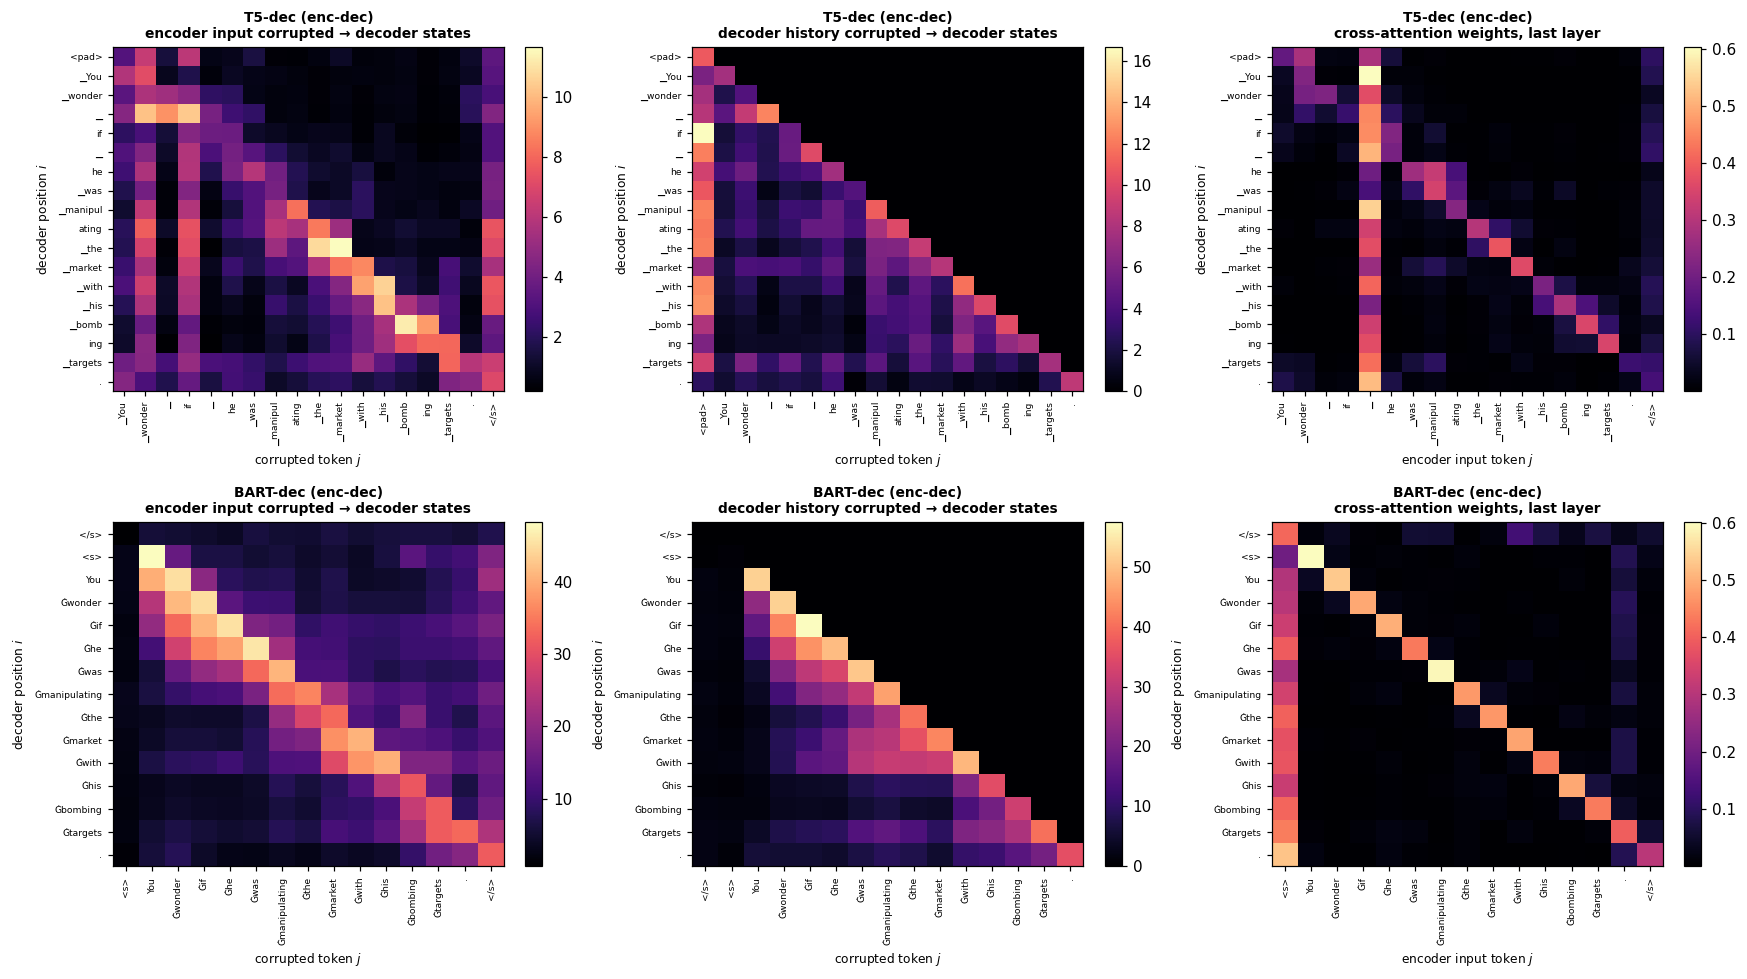

In [6]:
# ── Decoder: two masks, two influence matrices ───────────────────────
def cross_attention_map(label, sentence):
    """Cross-attention of the last decoder layer, averaged over heads."""
    model, tok = S2S[label], TOK[label]
    enc = tok(sentence, return_tensors="pt")
    with torch.no_grad():
        out = model(**enc, decoder_input_ids=shift_right(enc["input_ids"], model),
                    output_attentions=True)
    return out.cross_attentions[-1][0].mean(0).numpy()


def decoder_influence(label, sentence):
    """(source, history): influence of corrupting the encoder input and the decoder history."""
    model, tok = S2S[label], TOK[label]
    enc = tok(sentence, return_tensors="pt")
    ids = enc["input_ids"]
    n = ids.shape[1]
    dec_in = shift_right(ids, model)

    def dec_states(input_ids, decoder_input_ids):
        with torch.no_grad():
            out = model(input_ids=input_ids,
                        attention_mask=torch.ones_like(input_ids),
                        decoder_input_ids=decoder_input_ids)
        return out.last_hidden_state[0]

    base = dec_states(ids, dec_in)
    unk = tok.unk_token_id if tok.unk_token_id is not None else tok.pad_token_id

    M_src, M_hist = np.zeros((n, n)), np.zeros((n, n))
    for j in range(n):
        corrupted = ids.clone()
        corrupted[0, j] = unk
        M_src[:, j] = (dec_states(corrupted, dec_in) - base).norm(dim=-1).numpy()

        hist = dec_in.clone()
        hist[0, j] = unk
        M_hist[:, j] = (dec_states(ids, hist) - base).norm(dim=-1).numpy()

    return M_src, M_hist, tok.convert_ids_to_tokens(ids[0]), tok.convert_ids_to_tokens(dec_in[0])


fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for row, label in enumerate(S2S_IDS):
    M_src, M_hist, src_toks, hist_toks = decoder_influence(label, CAUSAL_TEST_SENTENCE)
    n = M_src.shape[0]
    denom = n * (n - 1) / 2
    print(f"{label:20s} encoder input corrupted : future = {np.triu(M_src, 1).sum() / denom:7.4f}"
          f" | past = {np.tril(M_src, -1).sum() / denom:7.4f}")
    print(f"{'':20s} decoder history corrupted: future = {np.triu(M_hist, 1).sum() / denom:7.4f}"
          f" | past = {np.tril(M_hist, -1).sum() / denom:7.4f}")

    for col, (M, toks, title) in enumerate([
        (M_src, src_toks, "encoder input corrupted → decoder states"),
        (M_hist, hist_toks, "decoder history corrupted → decoder states"),
        (cross_attention_map(label, CAUSAL_TEST_SENTENCE), src_toks,
         "cross-attention weights, last layer"),
    ]):
        ax = axes[row, col]
        im = ax.imshow(M, cmap="magma", aspect="auto")
        ax.set_title(f"{label}\n{title}", fontsize=9, fontweight="bold")
        ax.set_xlabel("encoder input token $j$" if col == 2 else "corrupted token $j$",
                      fontsize=8)
        ax.set_ylabel("decoder position $i$", fontsize=8)
        ax.set_xticks(range(len(toks)))
        ax.set_xticklabels(toks, rotation=90, fontsize=6)
        ax.set_yticks(range(len(hist_toks)))
        ax.set_yticklabels(hist_toks, fontsize=6)
        plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

#### **What we see**

**The decoder self-attention is indeed causal** — the mass on the future is exactly 0.0 for both models. Inside itself the decoder behaves just like GPT-2.

**But its access to the input is not causal.** The shape of cross-attention is `[batch, heads, decoder positions, encoder positions]`, and there is no mask there: every decoder state sees the **whole** input, from the very first generation step. So the phrase "the decoder is causal" is only true about its own history Y, not about the input.

The right column of the heatmap shows how this works: rows are decoder positions, columns are encoder positions, and every row spreads its attention over the whole input.

###

The fact worth taking out of this footnote:

> In an encoder-decoder the "embedding of the text" is the **encoder output**. A decoder state is not the meaning of the input but a **pointer** into the encoder space plus the state of generation. Analysing `decoder_hidden_states` as if they were sentence embeddings in the pure sense is no longer quite correct. It is an analysis of `decoder_hidden_states` conditioned on what was in the encoder (which is where the true sentence embeddings are).

## **Part 2. Measuring the mask**

### **Fact 1: informativeness — who saw how much and who weighs how much**

The mask is checked. Now let us take Fact 1 from the theory.

### **2.1 Context saturation**

Let $h_i(x_{1, \dots, k})$ denote the state of token $i$ at the moment when the model has seen all tokens up to the $k$-th. Then the representation of token $i$ when the model first saw it is $h_i(x_{1..i})$, and $h_i(x_{1..n})$ is the one where the model has seen every token.

**An example on three tokens.** Let the text be «she saw ducks», and let us follow the middle token, `saw`.

- **A causal model.** Given `she saw`, it computes $h_2(x_{1..2})$. Give it the whole sentence, `she saw ducks` — at position 2 it computes exactly the same thing: the token `ducks` is to the right, and to the right it does not look. The two vectors **coincide**, the angle between them is zero, $\cos = 1$.
- **A bidirectional model.** Given `she saw`, it builds $h_2$ from two words; given `she saw ducks`, from three. And `ducks` changes how `saw` is read: it is the verb, not the noun "saw" the tool. The vector **rotates**, $\cos < 1$.

If you draw those two vectors from the origin, in a causal model they lie on top of each other, and in a bidirectional one there is a visible angle between them.

The state of a token at any moment is a vector. A vector has a norm and a direction — let us exploit both for the analysis. First, to compare two vectors (the state of token $i$ with the full text and with the text cut exactly at it) we take:

$$\text{sat}(i) = \cos\bigl(h_i(x_{1..n}),\; h_i(x_{1..i})\bigr)$$

**How to read it:**
- $\text{sat}(i) = 1$ — the cosine of zero. The vectors have collapsed onto each other: the right context changed nothing about the direction.
- $\text{sat}(i) \ll 1$ — the representation of the token gets rewritten by whatever comes after it (it moves in direction).

For a causal model the answer is known analytically in advance — there $h_i$ does not depend on $x_{>i}$ at all, so it has to be exactly 1.

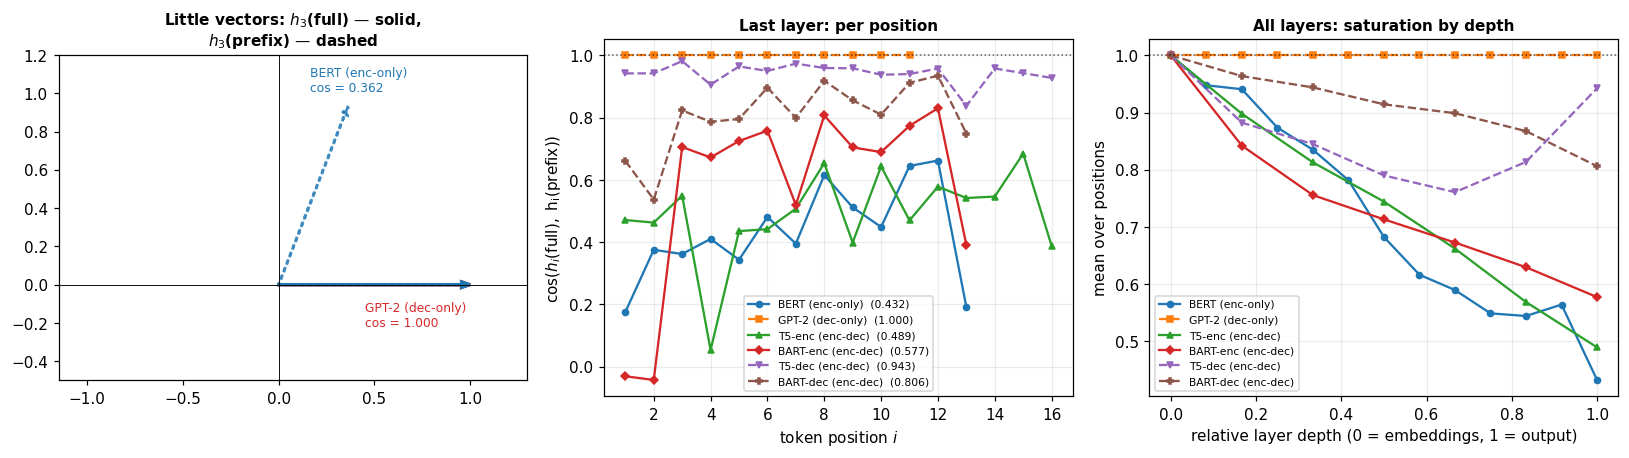

Type                        last layer  min over positions   min over layers
BERT (enc-only)                 0.4320            0.1755          0.4320
GPT-2 (dec-only)                1.0000            1.0000          1.0000
T5-enc (enc-dec)                0.4892            0.0534          0.4892
BART-enc (enc-dec)              0.5771           -0.0428          0.5771
T5-dec (enc-dec)                0.9426            0.8381          0.7607
BART-dec (enc-dec)              0.8061            0.5368          0.8061


In [7]:
# ── Context saturation: cos(h_i(full text), h_i(prefix up to i)) ─────
def context_saturation(model, tok, sentence):
    """sat[L, i] — the cosine at layer L for position i. L = 0 is the embeddings."""
    ids = tok(sentence, return_tensors="pt")["input_ids"]
    n = ids.shape[1]
    with torch.no_grad():
        full = model(input_ids=ids, output_hidden_states=True).hidden_states

    sat = np.zeros((len(full), n - 2))
    for i in range(1, n - 1):
        with torch.no_grad():
            prefix = model(input_ids=ids[:, : i + 1], output_hidden_states=True).hidden_states
        for L in range(len(full)):
            sat[L, i - 1] = torch.nn.functional.cosine_similarity(
                full[L][0, i], prefix[L][0, i], dim=0
            ).item()
    return sat


SAT = {label: context_saturation(MODEL[label], TOK[label], CAUSAL_TEST_SENTENCE)
       for label in ALL_LABELS}


def two_vectors_2d(model, tok, sentence, i):
    """The real h_i(full) and h_i(prefix) in the plane they span.

    We compute in float64: GPT-2 norms are around 300, and in float32 the
    difference of two almost identical vectors is pure rounding noise, out of
    which no "plane" can be built.
    """
    ids = tok(sentence, return_tensors="pt")["input_ids"]
    with torch.no_grad():
        u = model(input_ids=ids).last_hidden_state[0, i]
        v = model(input_ids=ids[:, : i + 1]).last_hidden_state[0, i]
    u = u.numpy().astype(np.float64)
    v = v.numpy().astype(np.float64)

    e1 = u / np.linalg.norm(u)
    w = v - (v @ e1) * e1
    if np.linalg.norm(w) < 1e-5 * np.linalg.norm(v):      # the vectors coincided
        return np.array([1.0, 0.0]), np.array([1.0, 0.0])
    e2 = w / np.linalg.norm(w)
    return np.array([1.0, 0.0]), np.array([v @ e1, v @ e2]) / np.linalg.norm(v)


fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) little vectors: the same two states, but visually
I_SHOW = 3
for label, color in zip(["GPT-2 (dec-only)", "BERT (enc-only)"], ["tab:red", "tab:blue"]):
    a, b = two_vectors_2d(MODEL[label], TOK[label], CAUSAL_TEST_SENTENCE, I_SHOW)
    axes[0].arrow(0, 0, *a, color=color, lw=2, head_width=0.03, length_includes_head=True)
    axes[0].arrow(0, 0, *b, color=color, lw=2, ls=":", head_width=0.03,
                  length_includes_head=True, alpha=0.85)
    off = 0.08 if b[1] > 0.05 else -0.22   # label overlapping arrows from below
    axes[0].annotate(f"{label}\ncos = {a @ b:.3f}", xy=b, xytext=(b[0] * 0.45, b[1] + off),
                     fontsize=8, color=color)
axes[0].set_xlim(-1.15, 1.3); axes[0].set_ylim(-0.5, 1.2)
axes[0].axhline(0, color="k", lw=0.6); axes[0].axvline(0, color="k", lw=0.6)
axes[0].set_aspect("equal")
axes[0].set_title(f"Little vectors: $h_{{{I_SHOW}}}$(full) — solid,\n"
                  f"$h_{{{I_SHOW}}}$(prefix) — dashed", fontsize=10, fontweight="bold")

# (b) per position, last layer 
for label, marker in zip(ALL_LABELS, MARKERS):
    s = SAT[label][-1]
    axes[1].plot(range(1, len(s) + 1), s, marker + style(label), ms=4,
                 label=f"{label}  ({s.mean():.3f})")
axes[1].axhline(1.0, color="k", ls=":", lw=1, alpha=0.6)
axes[1].set_xlabel("token position $i$")
axes[1].set_ylabel(r"$\cos(h_i(\rm full),\ h_i(\rm prefix))$")
axes[1].set_title("Last layer: per position", fontsize=10, fontweight="bold")
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.25)

# (c) along the depth: mean over positions at each layer, x = relative depth
for label, marker in zip(ALL_LABELS, MARKERS):
    m = SAT[label].mean(axis=1)
    depth = np.arange(len(m)) / (len(m) - 1)
    axes[2].plot(depth, m, marker + style(label), ms=4, label=label)
axes[2].axhline(1.0, color="k", ls=":", lw=1, alpha=0.6)
axes[2].set_xlabel("relative layer depth (0 = embeddings, 1 = output)")
axes[2].set_ylabel("mean over positions")
axes[2].set_title("All layers: saturation by depth", fontsize=10, fontweight="bold")
axes[2].legend(fontsize=7)
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"{'Type':22s} {'last layer':>15s} {'min over positions':>19s} {'min over layers':>17s}")
for label in ALL_LABELS:
    s = SAT[label]
    print(f"{label:22s} {s[-1].mean():15.4f} {s[-1].min():17.4f} {s.mean(axis=1).min():15.4f}")

### **What we see**

- **GPT-2 gives 1 at every position.** That is exactly what the phrase "in a causal model the early tokens are under-contextualised" means. Every token gets its own direction and never changes it as more context arrives.

- **All three bidirectional models are noticeably below one**: 0.432 for BERT, 0.489 for the T5 encoder, 0.577 for the BART encoder, and at individual positions the values drop to zero and even go negative. That is, the right context rewrites the token representation almost completely.

- **And the T5 and BART decoders are below one too — which is not a contradiction.** When we cut the text, we cut the **encoder** input, and the decoder reads it through cross-attention with no mask at all. Only its own history is causal (we checked that in part 1), so in this test it behaves like a bidirectional model. Exactly the same thing happens in any RAG-like pipeline: "a decoder model" and "a model whose representation does not depend on the right context" are not synonyms.

- **Along the depth the picture is the same for everyone:** at layer zero (the embeddings) saturation equals one for every type, simply because a token embedding has not seen any context yet, and from the first layer on the bidirectional types slide down. So "under-contextualisation" is a property of the whole depth, not of the output.

The practical consequence:

> `.mean(dim=1)` over the tokens of a decoder model (GPT-2 here) averages vectors, some of which physically contain no information about the text. The first token saw one word. The second one saw two. That average is **systematically** biased towards the beginning of the text.
    For encoder models like BERT the same operation is meaningful: there every position saw everything.

### **2.2 Attention sink: the first token as a drain valve**

The second factor of informativeness is not "what the token saw" but "how much attention it received".

There is a known effect in attention analysis: the first position collects a disproportionately large share of attention ([Xiao et al., 2023](https://arxiv.org/abs/2309.17453), StreamingLLM). The effect is called an attention sink. It appears because a softmax row has to sum to one — a head **cannot** "look nowhere". When a head has nothing to search for at this step, it still has to dump its attention mass somewhere, and the most convenient dump is a position that is visible from everywhere and carries no content. Hence the name — **attention sink**.

> **Formally.** Let $a^{(\ell,h)}_{ij}$ be the attention weight of head $h$ in layer $\ell$ from query position $i$ to key position $j$. We define the sink as
>
> $$\text{sink}(\ell) = \operatorname*{median}_{h,\, i}\ a^{(\ell,h)}_{i0}$$
>
> — the median share of attention going into position 0, over all heads and all queries of the layer. A median and not a mean, and that matters: the shares across heads are extremely skewed, one sink head with a share of 0.95 drags the mean up and creates the impression that the whole layer is leaking. The median answers the honest question — "how does a **typical** head behave".
>
> **A toy example: where the sink comes from arithmetically.** A softmax row is normalised for any logits: $\sum_j a_{ij} = 1$. Suppose query $q_i$ has no meaningful match at all — every $\langle q_i, k_j \rangle \approx 0$ — but position 0 has logit $s_0$ (the key there is always the same one, and the model learns it at no cost). Then
>
> $$a_{i0} = \frac{e^{s_0}}{e^{s_0} + (n - 1)}$$
>
> At $n = 15$ it takes only $s_0 \approx 4$ for more than 80% of the attention to go into position 0. No semantics whatsoever: the head simply has nowhere else to put the mass, and position zero is the one address that is always available. We will draw this curve next to the real shares.

This effect is usually described as a property of decoder models. Let us check whether that is so, and how encoders behave — we will compute the share of attention mass going into position 0, layer by layer.

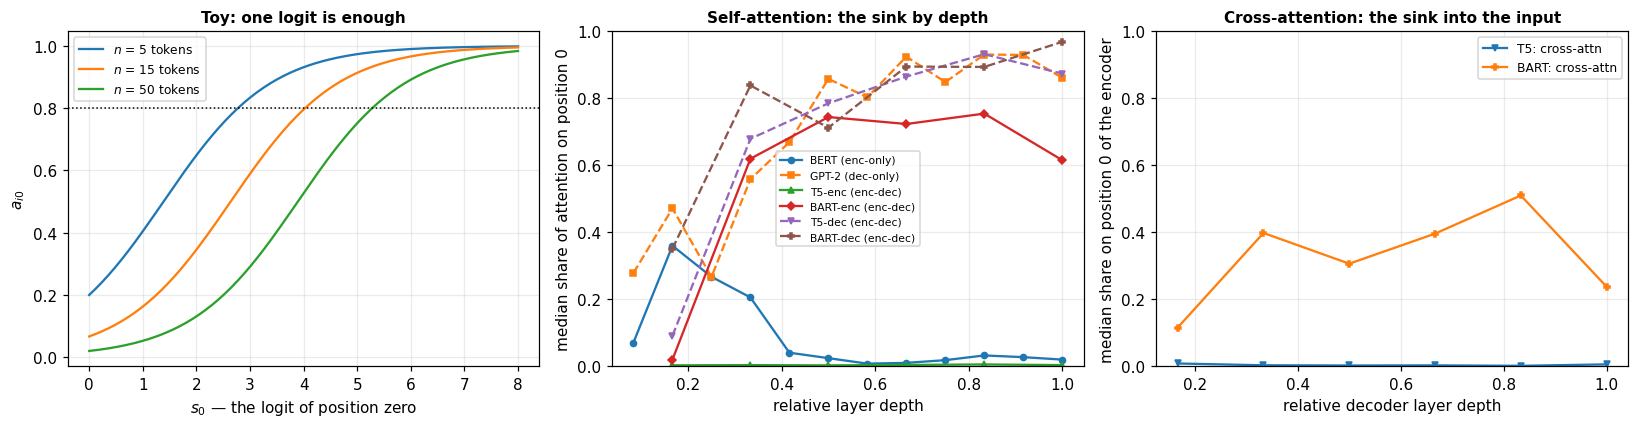

type                        first token  median sink per layer
BERT (enc-only)                   [CLS]  0.07 0.36 0.27 0.21 0.04 0.02 0.01 0.01 0.02 0.03 0.03 0.02
GPT-2 (dec-only)          <|endoftext|>  0.28 0.47 0.27 0.56 0.67 0.86 0.80 0.92 0.85 0.93 0.93 0.86
T5-enc (enc-dec)                   ▁You  0.00 0.00 0.00 0.00 0.01 0.00
BART-enc (enc-dec)                  <s>  0.02 0.62 0.74 0.72 0.75 0.61
T5-dec (enc-dec)                  <pad>  0.09 0.68 0.78 0.86 0.93 0.87
BART-dec (enc-dec)                 </s>  0.35 0.84 0.71 0.89 0.89 0.97
T5-dec (enc-dec) / cross                —  0.01 0.00 0.00 0.00 0.00 0.01
BART-dec (enc-dec) / cross                —  0.12 0.40 0.31 0.40 0.51 0.24


In [8]:
# ── Attention sink: share of attention mass landing on position 0 ────
# Note: transformers 5.x defaults to SDPA, and with it output_attentions=True
# silently returns []. That is why everything above is loaded with eager.
def _with_bos(tok, sentence, add_bos):
    enc = tok(sentence, return_tensors="pt")
    if add_bos:  # GPT-2 has no BOS by default — we put eos there instead
        enc["input_ids"] = torch.cat(
            [torch.tensor([[tok.eos_token_id]]), enc["input_ids"]], dim=1
        )
        enc["attention_mask"] = torch.ones_like(enc["input_ids"])
    return enc


def attention_sink(model, tok, sentence, add_bos=False, which="self"):
    """Median share of attention landing on position 0, per layer.

    Median over heads and queries: the distribution across heads is very
    skewed, and a single sink head would drag the mean up for the whole layer.
    """
    enc = _with_bos(tok, sentence, add_bos)
    with torch.no_grad():
        out = model(**enc, output_attentions=True)

    atts = out.attentions if which == "self" else out.cross_attentions
    assert atts, "empty attentions — the model was not loaded with eager"
    # a: [batch, heads, queries, keys] -> median over heads and queries, column 0
    return [float(a[0][:, :, 0].median()) for a in atts]


SINK = {
    label: attention_sink(
        MODEL[label], TOK[label], CAUSAL_TEST_SENTENCE, add_bos=("GPT-2" in label)
    )
    for label in ALL_LABELS
}
CROSS_SINK = {
    label: attention_sink(MODEL[label], TOK[label], CAUSAL_TEST_SENTENCE, which="cross")
    for label in S2S_IDS
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))

# (a) toy: how much mass goes into position 0 given one learned logit
s0 = np.linspace(0, 8, 200)
for n in (5, 15, 50):
    axes[0].plot(s0, np.exp(s0) / (np.exp(s0) + (n - 1)), label=f"$n$ = {n} tokens")
axes[0].axhline(0.8, color="k", ls=":", lw=1)
axes[0].set_xlabel("$s_0$ — the logit of position zero")
axes[0].set_ylabel("$a_{i0}$")
axes[0].set_title("Toy: one logit is enough", fontsize=10, fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

# (b) the real sink by relative depth
for label, marker in zip(ALL_LABELS, MARKERS):
    v = SINK[label]
    depth = (np.arange(len(v)) + 1) / len(v)
    axes[1].plot(depth, v, marker + style(label), ms=4, label=label)
axes[1].set_xlabel("relative layer depth")
axes[1].set_ylabel("median share of attention on position 0")
axes[1].set_title("Self-attention: the sink by depth", fontsize=10, fontweight="bold")
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.25)
axes[1].set_ylim(0, 1)

# (c) cross-attention: the sink into position 0 of the encoder
for label, marker in zip(S2S_IDS, MARKERS[4:]):
    v = CROSS_SINK[label]
    depth = (np.arange(len(v)) + 1) / len(v)
    axes[2].plot(depth, v, marker + "-", ms=4, label=label.split(" ")[0].replace("-dec", "") + ": cross-attn")
axes[2].set_xlabel("relative decoder layer depth")
axes[2].set_ylabel("median share on position 0 of the encoder")
axes[2].set_title("Cross-attention: the sink into the input", fontsize=10, fontweight="bold")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.25)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"{'type':22s} {'first token':>16s}  median sink per layer")
for label in ALL_LABELS:
    first_tok = TOK[label].convert_ids_to_tokens(
        _with_bos(TOK[label], CAUSAL_TEST_SENTENCE, "GPT-2" in label)["input_ids"][0][:1]
    )[0]
    if label in S2S_IDS:
        first_tok = TOK[label].convert_ids_to_tokens(
            [S2S[label].config.decoder_start_token_id]
        )[0]
    print(f"{label:22s} {first_tok:>16s}  " + " ".join(f"{x:.2f}" for x in SINK[label]))
for label in S2S_IDS:
    print(f"{label + ' / cross':22s} {'—':>16s}  " + " ".join(f"{x:.2f}" for x in CROSS_SINK[label]))

### **What we see**

**For GPT-2, by median: in the deep layers up to 93% of all attention goes into the first token.** The model almost stops "looking at the text" and drains attention into the sink.

The BART encoder — a **bidirectional** model — shows a sink of almost the same strength: 0.61–0.75 from the second layer on. So the draining is not a consequence of the architecture alone; it also depends on the presence of a service token. Specifically, for our models the following holds:

| type | mask | first token | sink (median over heads and queries) |
|---|---|---|---|
| GPT-2 | causal | BOS (we added it) | **up to 0.93** |
| BART encoder | bidirectional | `<s>`, always | **up to 0.75** |
| BERT | bidirectional | `[CLS]`, always | 0.36 early on, then 0.01–0.03 |
| T5 encoder | bidirectional | **absent** | 0.00–0.01, no sink |
| T5 decoder | causal | `<pad>` as `decoder_start` | **up to 0.93** |
| BART decoder | causal | `</s>` as `decoder_start` | **up to 0.97** |

- GPT-2 and BART have one, and it works as a dump through the whole depth. BERT has `[CLS]`, but the sink only holds in the early layers. T5 has no initial service token — and no sink.

- The T5 encoder and the T5 decoder are one model: one pretraining run, one tokenizer, one normalisation scheme, the same number of layers and heads. What differs between them is the mask and the presence of a start token. The encoder has no initial service token and no sink: 0.00–0.01 across all six layers. The decoder of that same T5 starts the sequence with `<pad>` — and the sink reaches 0.93. The effect switches on exactly where a permanently empty position appears.

- Cross-attention is not masked in T5 or in BART — the mask plays no part here. And still: in BART up to 0.51 leaks into position 0 of the encoder, while in T5 it is 0.00–0.01. The difference between them is exactly the difference between their encoders, and it has the same explanation: BART has `<s>` at position 0, T5 has an ordinary word.

> The numbers above are computed on a single sentence, but they are stable: on 12 random sentences from the corpus the median of the per-layer maximum sink is 0.93 for GPT-2 (spread 0.86–0.96), 0.96 for the BART decoder, 0.90 for the T5 decoder, 0.75 for the BART encoder, 0.35 for BERT and 0.01 for the T5 encoder — the ordering of the types does not change.

> So the mechanism is this: a head needs a place to dump the excess attention mass, and the best candidate is a position that is **always present, visible from everywhere and carries no content**. Which means our **service first token is part of the attention machinery, not a carrier of meaning.** Putting it into mean-pooling is not quite right — we would be mixing into the "text embedding" a vector with a service role and, as we will see below, an anomalous magnitude. This concerns GPT-2, BART, BERT and both decoders — that is, everyone who has such a token.

### **2.3 Norms: two orders of magnitude apart**

The attention sink has a geometric twin — **anomalously large norms** at service positions (they are called massive activations, [Sun et al., 2024](https://arxiv.org/abs/2402.17762)).

Let us look at the effect in action.

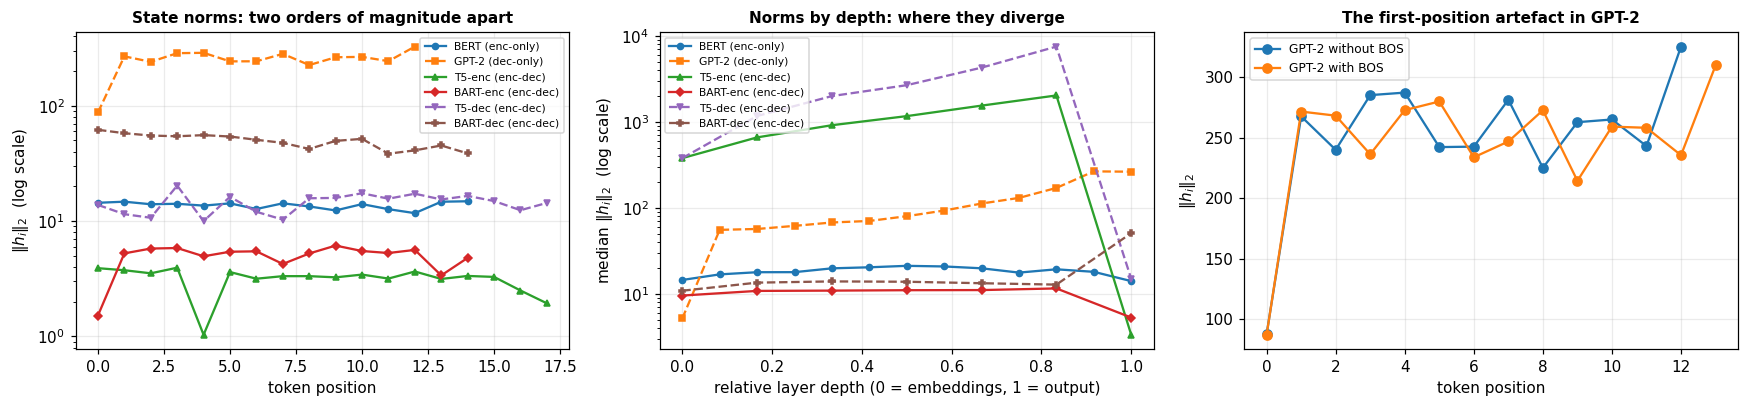

BERT (enc-only)        median norm =   14.03   max =   14.85
GPT-2 (dec-only)       median norm =  262.88   max =  325.44
T5-enc (enc-dec)       median norm =    3.33   max =    3.94
BART-enc (enc-dec)     median norm =    5.29   max =    6.14
T5-dec (enc-dec)       median norm =   14.92   max =   20.30
BART-dec (enc-dec)     median norm =   50.65   max =   61.83

One model, two types — how many times «bigger» the decoder is than its encoder:
  T5-dec (enc-dec)        14.92 /  3.33 = 4.5x
  BART-dec (enc-dec)      50.65 /  5.29 = 9.6x

type                      layer 0   max over layers     output
BERT (enc-only)              14.5            21.1       14.0
GPT-2 (dec-only)              5.2           265.1      262.9
T5-enc (enc-dec)            378.0          2026.0        3.3
BART-enc (enc-dec)            9.5            11.5        5.3
T5-dec (enc-dec)            378.0          7500.7       14.9
BART-dec (enc-dec)           10.8            50.6       50.6


In [9]:
# ── Norms: per position, per depth, and the BOS artefact ─────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))

# (a) output norms for all six types
for label, marker in zip(ALL_LABELS, MARKERS):
    enc = TOK[label](CAUSAL_TEST_SENTENCE, return_tensors="pt")
    with torch.no_grad():
        H = MODEL[label](**enc).last_hidden_state[0]
    axes[0].plot(H.norm(dim=-1).numpy(), marker + style(label), ms=4, label=label)
axes[0].set_yscale("log")
axes[0].set_xlabel("token position")
axes[0].set_ylabel(r"$\|h_i\|_2$  (log scale)")
axes[0].set_title("State norms: two orders of magnitude apart", fontsize=10, fontweight="bold")
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.25)

# (b) the same norms along the depth: median over the positions of each layer
NORM_BY_LAYER = {}
for label, marker in zip(ALL_LABELS, MARKERS):
    enc = TOK[label](CAUSAL_TEST_SENTENCE, return_tensors="pt")
    with torch.no_grad():
        hs = MODEL[label](**enc, output_hidden_states=True).hidden_states
    med = [float(h[0].norm(dim=-1).median()) for h in hs]
    NORM_BY_LAYER[label] = med
    axes[1].plot(np.arange(len(med)) / (len(med) - 1), med,
                 marker + style(label), ms=4, label=label)
axes[1].set_yscale("log")
axes[1].set_xlabel("relative layer depth (0 = embeddings, 1 = output)")
axes[1].set_ylabel(r"median $\|h_i\|_2$  (log scale)")
axes[1].set_title("Norms by depth: where they diverge", fontsize=10, fontweight="bold")
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.25)

# (c) the first-position artefact in GPT-2
tok_g, mdl_g = TOK["GPT-2 (dec-only)"], MODEL["GPT-2 (dec-only)"]
for name, prefix in [("without BOS", []), ("with BOS", [tok_g.eos_token_id])]:
    ids = torch.tensor([prefix + tok_g.encode(CAUSAL_TEST_SENTENCE)])
    with torch.no_grad():
        H = mdl_g(input_ids=ids).last_hidden_state[0]
    axes[2].plot(H.norm(dim=-1).numpy(), "o-", label=f"GPT-2 {name}")
axes[2].set_xlabel("token position")
axes[2].set_ylabel(r"$\|h_i\|_2$")
axes[2].set_title("The first-position artefact in GPT-2", fontsize=10, fontweight="bold")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

MED_NORM = {}
for label in ALL_LABELS:
    enc = TOK[label](CAUSAL_TEST_SENTENCE, return_tensors="pt")
    with torch.no_grad():
        H = MODEL[label](**enc).last_hidden_state[0]
    nr = H.norm(dim=-1)
    MED_NORM[label] = float(nr.median())
    print(f"{label:22s} median norm = {nr.median():7.2f}   max = {nr.max():7.2f}")

print("\nOne model, two types — how many times «bigger» the decoder is than its encoder:")
for dec, enc_label in (("T5-dec (enc-dec)", "T5-enc (enc-dec)"),
                       ("BART-dec (enc-dec)", "BART-enc (enc-dec)")):
    print(f"  {dec:22s} {MED_NORM[dec]:6.2f} / {MED_NORM[enc_label]:5.2f} = "
          f"{MED_NORM[dec] / MED_NORM[enc_label]:.1f}x")

print(f"\n{'type':22s} {'layer 0':>10s} {'max over layers':>17s} {'output':>10s}")
for label in ALL_LABELS:
    med = NORM_BY_LAYER[label]
    print(f"{label:22s} {med[0]:10.1f} {max(med):15.1f} {med[-1]:10.1f}")


### **What we see**

Median norms: 3.3 for the T5 encoder, 5.3 for the BART encoder, 14.0 for BERT and **263** for GPT-2. **Two orders of magnitude apart.** Plus the two decoders: 14.9 for T5 and 50.7 for BART.

The reason is simply the normalisation scheme: BERT uses post-LayerNorm, GPT-2 uses pre-LayerNorm with a final `ln_f`, T5 uses RMSNorm without a learned shift, BART uses ordinary LayerNorm. That is an architectural detail which should ideally be taken into account everywhere you use norms.

**And here you can see that the decoder space lives at a different scale than the space of its own encoder.** For T5 the median norms are 3.33 against 14.92 — a ratio of 4.5. For BART, 5.29 against 50.65 — a ratio of 9.6. One forward pass, one model, the same weights — and a difference of several times, in both architectures.

That alone is reason enough never to add up or cosine encoder and decoder states together. And the fact that the effect reproduced on two independently built encoder-decoders moves it from "a quirk of T5" to a property of the architecture class.

> A rule that helps me in practice: **any scale-sensitive metric compared across architectures needs normalisation.** And on top of that, any metric needs a baseline.

Beyond statistics on individual examples, we can analyse more general things. Let us look at the structures — the point clouds — that an architecture can produce.

# **Part 3. Geometry**

Point clouds can be characterised in many ways. I subjectively picked three pretty ones. Three — so that the tutorial does not get too wide, we have sprawled enough as it is.

I assume the maths may be unfamiliar, or partly unfamiliar. So let us first fix the intuition and only then the formal definitions. We will look at:

- **Anisotropy** in the general sense — the dependence of the mathematical properties of an object, a function, a space or a model on direction. We will be estimating the isotropy of a space, that is, the opposite — how alike all directions in the model are. Do not let the long word scare you: it is just a pairwise cosine here.
- **The spectrum and the participation ratio** — matrix characteristics that tell how many effective directions there are.
- **CKA** — a metric that lets us analyse how similar models are to one another (in the sense of how their spaces are organised).

If that felt heavy, we are about to unpack it section by section.

In [10]:
# ── Building the token clouds ────────────────────────────────────────
N_TEXTS = 300
MAX_LEN = 48

ag = load_dataset("fancyzhx/ag_news", split="train").shuffle(seed=SEED)
AG_TEXTS = [t[:180] for t in ag.select(range(N_TEXTS))["text"]]


def collect_token_cloud(model, tok, texts, batch_size=16, max_len=MAX_LEN):
    """All last-layer token states + the sentence each token came from.

    Padding positions are dropped: they carry no information and would
    contaminate every geometric metric downstream.
    """
    vecs, sent_ids = [], []
    for start in range(0, len(texts), batch_size):
        batch = texts[start : start + batch_size]
        enc = tok(batch, return_tensors="pt", padding=True, truncation=True, max_length=max_len)
        with torch.no_grad():
            H = model(**enc).last_hidden_state
        mask = enc["attention_mask"].bool()
        for b in range(H.shape[0]):
            n_real = int(mask[b].sum())
            vecs.append(H[b, :n_real])
            sent_ids.extend([start + b] * n_real)
    return torch.cat(vecs).float().numpy(), np.array(sent_ids)


# The decoder parts go through the very same function: the wrapper hides
# the fact that a full seq2seq forward pass happens inside.
CLOUD = {}
for label in ALL_LABELS:
    X, sid = collect_token_cloud(MODEL[label], TOK[label], AG_TEXTS)
    CLOUD[label] = {"X": X, "sid": sid}
    print(f"{label:18s} cloud: {X.shape[0]:6d} tokens x {X.shape[1]} dimensions")

BERT (enc-only)    cloud:  11924 tokens x 768 dimensions


GPT-2 (dec-only)   cloud:  11676 tokens x 768 dimensions


T5-enc (enc-dec)   cloud:  13113 tokens x 512 dimensions


BART-enc (enc-dec) cloud:  12220 tokens x 768 dimensions


T5-dec (enc-dec)   cloud:  13113 tokens x 512 dimensions


BART-dec (enc-dec) cloud:  12220 tokens x 768 dimensions


Different token counts are a consequence of the vocabulary. The word "greenhouse", for instance, is a single token for BERT and the T5 encoder but two tokens for GPT-2 and BART; "unbelievable" is one token for BERT and four for GPT-2.


## **3.1 Anisotropy**

**Theory.** A space is called **isotropic** if vectors drawn from it at random are almost orthogonal. For a Gaussian cloud in $\mathbb{R}^D$ that is the case: at large $D$ the cosine of two random vectors concentrates around zero.

The measure of the deviation from isotropy is the mean pairwise cosine ([Ethayarajh, 2019](https://arxiv.org/abs/1909.00512)):

$$A = \mathbb{E}_{i \ne j,\ s(i) \ne s(j)} \bigl[\cos(h_i, h_j)\bigr]$$

We take tokens from **different** sentences here. Inside one sentence tokens may be similar for perfectly natural reasons.

**How to read it:**
- $A \approx 0$ — isotropic, the cosine is informative: if two vectors are similar, that means something;
- $A \to 1$ — all vectors point roughly the same way; the cosine of any pair is ≈ 1 and it **carries no information**.

Our control is the **baseline** — the same estimate for a Gaussian cloud of the same dimensionality. Without it we cannot say whether a number is large or small, accidental or not. It also lets us compare $D=768$ with $D=512$ more fairly.

In [11]:
# ── Anisotropy: mean pairwise cosine of tokens from different sentences ──
def anisotropy(X, sent_ids, n_sample=2500, seed=SEED):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), min(n_sample, len(X)), replace=False)
    V = X[idx]
    V = V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-9)
    S = V @ V.T
    s = sent_ids[idx]
    cross_sentence = s[:, None] != s[None, :]
    return float(S[cross_sentence].mean())


print(f"{'type':22s} {'anisotropy':>12s} {'baseline':>10s}")
ANISO = {}
for label in ALL_LABELS:
    c = CLOUD[label]
    ANISO[label] = anisotropy(c["X"], c["sid"])
    D = c["X"].shape[1]
    G = np.random.default_rng(SEED).standard_normal((2000, D))
    base = anisotropy(G, np.arange(2000))
    print(f"{label:22s} {ANISO[label]:12.3f} {base:10.3f}")

type                     anisotropy   baseline
BERT (enc-only)               0.227     -0.000
GPT-2 (dec-only)              0.945     -0.000
T5-enc (enc-dec)              0.098     -0.000


BART-enc (enc-dec)            0.184     -0.000
T5-dec (enc-dec)              0.868     -0.000
BART-dec (enc-dec)            0.096     -0.000


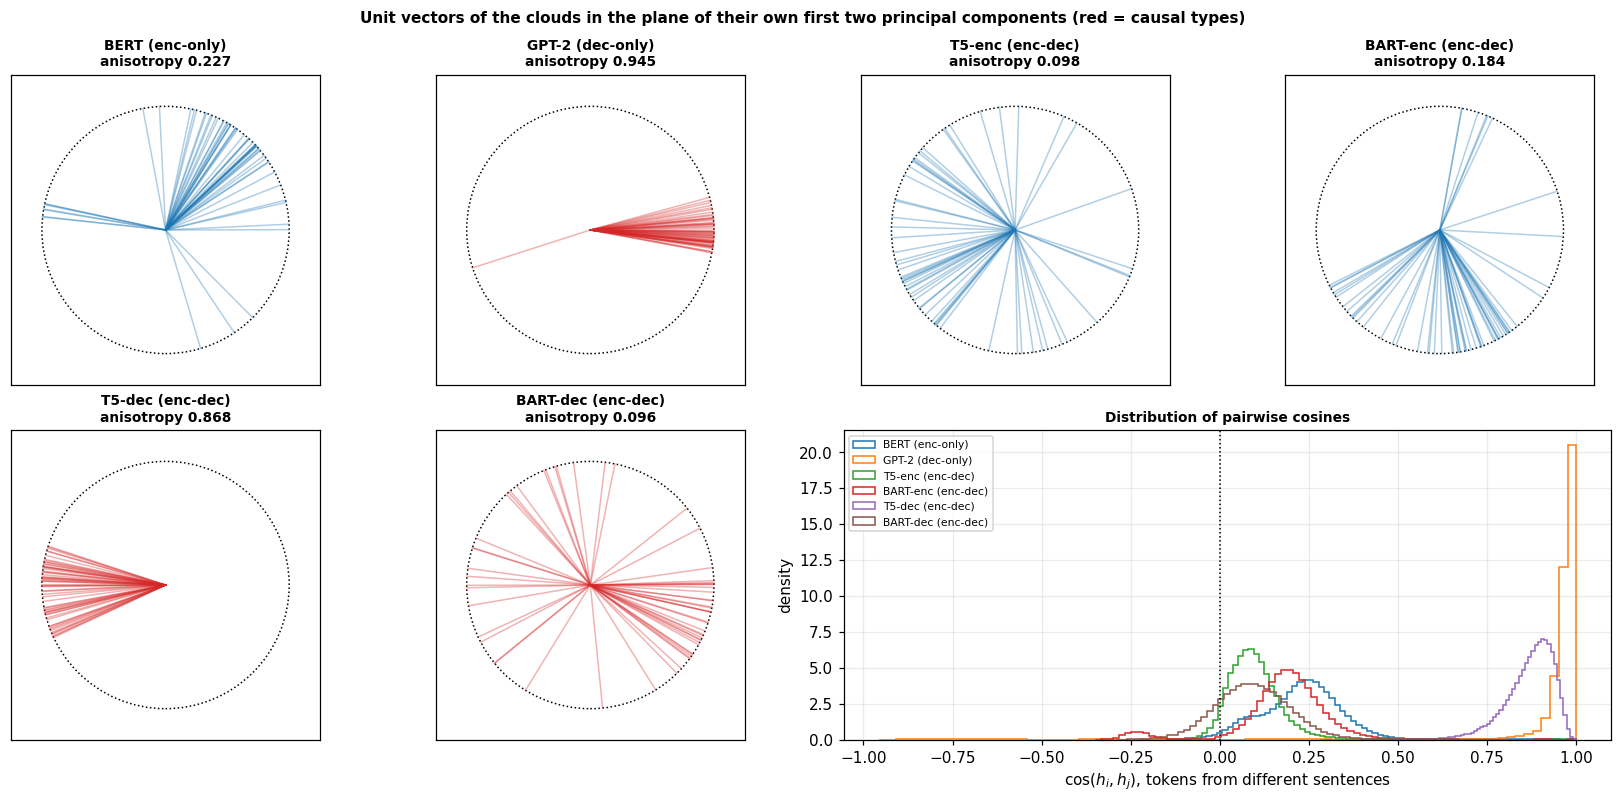

In [12]:
# ── What that number looks like: real vectors, real cosines ──────────
def unit_sample(label, n=60, seed=SEED):
    """n random tokens of the cloud, normalised, in the plane of the first two PCs."""
    c = CLOUD[label]
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(c["X"]), n, replace=False)
    V = c["X"][idx]
    basis = PCA(n_components=2).fit(c["X"]).components_    # axes for the picture only
    P = V @ basis.T
    return P / (np.linalg.norm(P, axis=1, keepdims=True) + 1e-9)


fig = plt.figure(figsize=(15, 7.4))
gs = fig.add_gridspec(2, 4)

# (a-f) unit vectors of each of the six clouds
for k, label in enumerate(ALL_LABELS):
    ax = fig.add_subplot(gs[k // 4, k % 4])
    color = "tab:red" if label in CAUSAL_STACKS else "tab:blue"
    for p in unit_sample(label):
        ax.plot([0, p[0]], [0, p[1]], color=color, alpha=0.35, lw=1)
    ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, color="k", ls=":", lw=1))
    ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{label}\nanisotropy {ANISO[label]:.3f}", fontsize=9, fontweight="bold")

# (g) the distribution of pairwise cosines — the same number, in full
axh = fig.add_subplot(gs[1, 2:])
rng = np.random.default_rng(SEED)
for label in ALL_LABELS:
    c = CLOUD[label]
    idx = rng.choice(len(c["X"]), 1500, replace=False)
    V = c["X"][idx]
    V = V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-9)
    S = V @ V.T
    cross = c["sid"][idx][:, None] != c["sid"][idx][None, :]
    axh.hist(S[cross], bins=80, histtype="step", lw=1.5, density=True,
             ls=style(label), label=label)
axh.axvline(0, color="k", ls=":", lw=1)
axh.set_xlabel(r"$\cos(h_i, h_j)$, tokens from different sentences")
axh.set_ylabel("density")
axh.set_title("Distribution of pairwise cosines", fontsize=9, fontweight="bold")
axh.legend(fontsize=7)
axh.grid(alpha=0.25)

fig.suptitle("Unit vectors of the clouds in the plane of their own first two principal components "
             "(red = causal types)", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()


### **What we see**

Look how pretty this is! In GPT-2 the rays are gathered into a narrow pencil — any pair of vectors is almost collinear — while in BERT and the T5 encoder they spread around the whole circle. On the right the same thing as a distribution: for GPT-2 the histogram of cosines is pressed against one, for the others it sits near zero with long tails.

- **GPT-2: 0.945.** Consequence: the vectors are collinear more often. So cosine similarity on the *output of GPT-2* **carries almost no information**.
- **BERT: 0.227.** Consequence: the vectors are collinear less often.
- **T5 encoder: 0.098** and **BART encoder: 0.184** — the "roundest" clouds.
- **Gaussian baseline: ~0.00** for both dimensionalities. It is exactly what tells us that 0.227 for BERT is *a lot*, not "almost zero".
- **And the decoders parted ways:** 0.868 for the T5 decoder — almost like GPT-2 — and 0.096 for the BART decoder — like the roundest encoders. Their mask is one and the same, causal, and the anisotropy differs ninefold.

The imprint of the model type is already visible: the only decoder-only collapses the space more than anyone else, while the three bidirectional encoders stay in the 0.10–0.23 range — even though their objectives are three different ones.

> But the enc-dec decoders immediately put a limit on that explanation: both are causal, yet they lie on opposite sides of the range. So "causality" by itself does not explain anisotropy — we will come back to this in 3.2, once we have more shape metrics.

> And for intuition, the picture above: on the left the unit vectors of the clouds in the plane of their own first two principal components, on the right the distribution of pairwise cosines. The 0.945 of GPT-2 is that narrow pencil, and the 0.098 of the T5 encoder is rays all around the circle.

### **What can be done about high anisotropy**

High anisotropy has two fundamentally different possible causes.

**Hypothesis A: the cloud really is flattened.** The vectors lie in a narrow cone, the directions inside it are correlated, the geometry truly is degenerate.

**Hypothesis B: the cloud is fine but shifted.** Picture a unit-radius ball centred at a point $\mu$ with $\|\mu\| = 10$. All points of that ball have almost the same direction — simply because the ball is far from the origin. The cosine between them will be ≈ 1, even though the **internal** structure of the cloud is perfectly normal.

The difference between A and B:
- if A — the space really is in trouble and there is little information in it;
- if B — the whole "trouble" is cured by subtracting the mean, and no information went anywhere.

They can be told apart with a simple hint — compute the anisotropy **after centering**, $\tilde h = h - \bar h$. On our data we get the following.

In [13]:
# ── Where the cone comes from: raw cloud vs centered cloud ───────────
rows = []
for label in ALL_LABELS:
    c = CLOUD[label]
    X = c["X"]
    Xc = X - X.mean(0)

    rows.append([
        label,
        anisotropy(X, c["sid"]),
        anisotropy(Xc, c["sid"]),
    ])

print(
    pd.DataFrame(
        rows, columns=["model", "raw", "after centering"]
    ).round(3).to_string(index=False)
)

             model   raw  after centering
   BERT (enc-only) 0.227           -0.000
  GPT-2 (dec-only) 0.945            0.007
  T5-enc (enc-dec) 0.098            0.000
BART-enc (enc-dec) 0.184           -0.000
  T5-dec (enc-dec) 0.868            0.007
BART-dec (enc-dec) 0.096           -0.000


#### **What we see**

**Anisotropy collapses to zero after a single subtraction of the mean — in all six types.** GPT-2: 0.945 → 0.007. BERT: 0.227 → −0.000. The BART encoder: 0.184 → −0.000. And the most "cone-shaped" of the decoders, T5: 0.868 → 0.007.

So **hypothesis B** is the one that holds. The notorious "representation cone" is not degenerate geometry but a **shift of the cloud away from the origin**. The information inside the cloud was there all along; it is just that the cosine, which measures angles **from the origin**, was looking in the wrong place.

And the consequence for our work:
> **Center before you take a cosine.** Always. And the mean has to be computed over the same distribution of texts you are working with. Without that you are measuring not the similarity of texts but the position of the common centre of mass — which is the same for every pair.

This also shows why, for example, `[CLS]` embeddings "work badly without normalisation" but behave fine after centering.

## **3.2 The spectrum: how many dimensions the model uses**

Now let us come at it from another side. A cloud has a covariance matrix, and that matrix has eigenvalues $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_D$. Their profile tells us over how many directions the variance is spread.

From them we can compute two (well, not only two, but the two most popular) statistics. Both are built so as not to depend on the overall scale:

**Participation ratio** — the "effective number of active directions":

$$\text{PR} = \frac{\left(\sum_d \lambda_d\right)^2}{\sum_d \lambda_d^2}$$

If all the variance is in one direction, $\text{PR} = 1$. If it is spread evenly over $k$ directions, $\text{PR} = k$.

**Effective rank** — the same idea, but through the entropy of the spectrum ([Roy & Vetterli, 2007](https://ieeexplore.ieee.org/document/7098875)):

$$\text{erank} = \exp\left(-\sum_d p_d \log p_d\right), \qquad p_d = \frac{\lambda_d}{\sum_k \lambda_k}$$

Both metrics depend on $D$, so once again we compute a Gaussian baseline: for an isotropic cloud in $\mathbb{R}^D$ both quantities should be of the order of $D$.

In [14]:
# ── Spectrum: participation ratio and effective rank ─────────────────
def spectrum_stats(X):
    Xc = X - X.mean(0)
    sv = np.linalg.svd(Xc, compute_uv=False)
    ev = sv ** 2 / (len(Xc) - 1)          # covariance eigenvalues
    p = ev / ev.sum()
    pr = ev.sum() ** 2 / (ev ** 2).sum()  # participation ratio (effective number of directions)
    erank = float(np.exp(-(p * np.log(p + 1e-12)).sum()))
    return {"PR": pr, "erank": erank, "p": p, "D": X.shape[1]}


SPEC = {}
rows = []
for label in ALL_LABELS:
    s = spectrum_stats(CLOUD[label]["X"])
    SPEC[label] = s
    rows.append([label, s["D"], s["PR"], s["erank"], s["p"][0], s["p"][:10].sum(),
                 s["PR"] / s["D"]])

# the Gaussian control is computed once and reused in the plot below
GAUSS = {D: spectrum_stats(np.random.default_rng(SEED).standard_normal((4000, D)))
         for D in sorted({SPEC[l]["D"] for l in ALL_LABELS})}
for D, s in GAUSS.items():
    rows.append([f"gauss D={D}", D, s["PR"], s["erank"], s["p"][0], s["p"][:10].sum(),
                 s["PR"] / D])

print(
    pd.DataFrame(
        rows, columns=["model", "D", "PR", "erank", "var@PC1", "var@10PC", "PR/D"]
    ).round(3).to_string(index=False)
)

             model   D      PR   erank  var@PC1  var@10PC  PR/D
   BERT (enc-only) 768  86.294 276.577    0.068     0.247 0.112
  GPT-2 (dec-only) 768   1.856   3.640    0.723     0.961 0.002
  T5-enc (enc-dec) 512 174.653 289.630    0.027     0.160 0.341
BART-enc (enc-dec) 768 112.859 307.103    0.051     0.226 0.147
  T5-dec (enc-dec) 512   3.377   9.482    0.515     0.874 0.007
BART-dec (enc-dec) 768  67.769 197.841    0.079     0.276 0.088
       gauss D=512 512 453.917 480.284    0.004     0.035 0.887
       gauss D=768 768 644.736 697.919    0.003     0.026 0.839


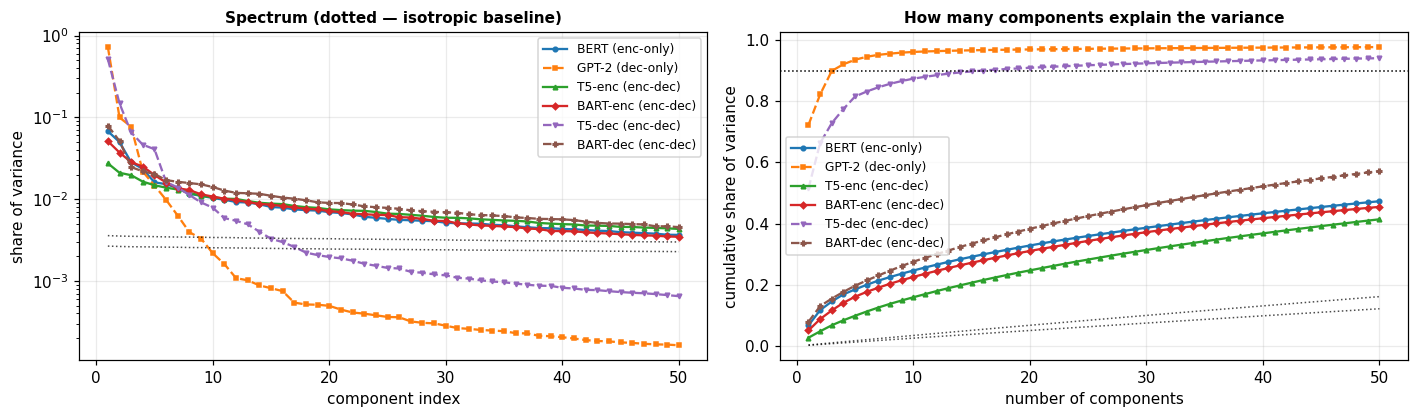

In [15]:
# ── Spectrum plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 3.9))

for label, marker in zip(ALL_LABELS, MARKERS):
    p = SPEC[label]["p"]
    axes[0].plot(np.arange(1, 51), p[:50], marker + style(label), ms=3, label=label)
    axes[1].plot(np.arange(1, 51), np.cumsum(p[:50]), marker + style(label), ms=3, label=label)

for D, s in GAUSS.items():
    p = s["p"]
    axes[0].plot(np.arange(1, 51), p[:50], "k:", lw=1, alpha=0.7)
    axes[1].plot(np.arange(1, 51), np.cumsum(p[:50]), "k:", lw=1, alpha=0.7)

axes[0].set_yscale("log")
axes[0].set_xlabel("component index")
axes[0].set_ylabel("share of variance")
axes[0].set_title("Spectrum (dotted — isotropic baseline)", fontsize=10, fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].set_xlabel("number of components")
axes[1].set_ylabel("cumulative share of variance")
axes[1].set_title("How many components explain the variance", fontsize=10, fontweight="bold")
axes[1].axhline(0.9, color="k", ls=":", lw=1)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

### **What we see**


- **GPT-2: PR ≈ 1.9 at $D = 768$.** The first principal component explains 72% of the variance, the first ten explain 96%. A cloud of thousands of token states, formally living in a 768-dimensional space, has in fact packed all its variance into about two directions.
- **BERT: PR ≈ 86**, effective rank ≈ 277, and the **BART encoder: PR ≈ 113** at the same $D = 768$. Two orders of magnitude "roomier" than GPT-2 at **exactly the same** dimensionality.
- **T5 encoder: PR ≈ 175** at $D = 512$ — relative to its own dimensionality the most distributed one.
- **Gaussian baseline: PR ≈ 645** at $D = 768$ and ≈ 454 at $D = 512$.
- **The decoders parted ways again:** PR ≈ 3.4 for the T5 decoder (PR/D = 0.007, that is, almost GPT-2) and PR ≈ 68 for the BART decoder (PR/D = 0.088, that is, almost its own encoder).

The `PR/D` column makes the comparison between different $D$ a bit fairer: 0.002 for GPT-2 against 0.112 for BERT, 0.147 for the BART encoder and 0.341 for the T5 encoder.

The difference is explained by the attention mask and the objective.

- **The objective decides what the output runs into.** In CLM the last layer is read by exactly one linear map — `lm_head`, that is $W_E^\top h$ with tied embedding weights. Whatever does not help to decompose $h$ along the rows of $W_E$ gets no variance: the direction useful for predicting the next token is amplified, the rest are squeezed. On top of that, the pre-LN architecture of GPT-2 accumulates a few giant coordinates in the residual stream (those very massive activations from section 2.3), and they take almost the entire trace of the covariance. Hence $\text{PR} \approx 2$: this is not "little information" but "all the variance folded into a couple of service directions".

In MLM the pressure is the opposite: **every** position has to allow its own token to be restored, so every position must carry both word identity and context. One direction cannot hold that — the variance spreads over dozens.

In span corruption and denoising the encoder output is not read by a linear classifier at all: it is read by the decoder through cross-attention, at every position and at every layer at once. Such a representation is better kept "wide" — hence the largest PR/D for the T5 and BART encoders.

- **The mask decides how many independent roles the positions have.** In a bidirectional type all positions are equal and each sees the whole text, so the token cloud is a cloud of *different* contextualised meanings. In a causal type position $i$ sees only the prefix, and neighbouring positions differ by exactly one token: the states form an almost nested chain, strongly correlated along the text. Such a cloud is narrower than a bidirectional one by construction. At least that is what intuition suggests — and it is intuition that we are about to test.

Hence the full conclusion: **the shape of the cloud is set not by the mask but by whatever reads the output, plus the normalisation scheme.** The mask enters only indirectly — through the fact that a causal output is usually read by a single linear head.

What is determined by the mask, then? Not the shape but the **similarity structure** — "which texts this model considers similar". That is exactly what we will measure in 3.3. Spoiler: a correction awaits us there too, and again it comes from the decoders.

## **3.3 Comparing two spaces with each other**

We have described every cloud separately. Now to the final part — let us estimate **how similar the spaces of two different models are**.

The naive answer — "let us take the cosine between BERT and GPT-2 embeddings" — is not merely bad, it is **undefined**. The coordinates $h^{\text{BERT}}_5$ and $h^{\text{GPT-2}}_5$ are different numbers about different things; there is no correspondence between the bases of two independently trained models. And for T5 the dimensionalities do not even match.

The classic way to measure two spaces properly is **linear CKA** (Centered Kernel Alignment, [Kornblith et al., 2019](https://arxiv.org/abs/1905.00414)):

$$\text{CKA}(X, Y) = \frac{\|Y^\top X\|_F^2}{\|X^\top X\|_F \cdot \|Y^\top Y\|_F}, \qquad X, Y \text{ centered}$$

CKA compares not coordinates but the **matrices of pairwise similarities between objects**: "do these two spaces agree on which texts are similar to one another". Hence its invariance to orthogonal rotations and to isotropic scaling, and hence it works at different $D$.

In [16]:
# ── Comparing spaces: linear CKA across different D ──────────────────
def linear_cka(X, Y):
    """Similarity of two representation spaces; works across different D."""
    X = X - X.mean(0)
    Y = Y - Y.mean(0)
    return float(
        np.linalg.norm(Y.T @ X, "fro") ** 2
        / (np.linalg.norm(X.T @ X, "fro") * np.linalg.norm(Y.T @ Y, "fro"))
    )


def mean_pool(model, tok, texts, batch_size=16, max_len=MAX_LEN):
    """Sentence representations by masked mean pooling."""
    out = []
    for start in range(0, len(texts), batch_size):
        enc = tok(texts[start : start + batch_size], return_tensors="pt",
                  padding=True, truncation=True, max_length=max_len)
        with torch.no_grad():
            H = model(**enc).last_hidden_state
        m = enc["attention_mask"].unsqueeze(-1).float()
        out.append((H * m).sum(1) / m.sum(1))
    return torch.cat(out).float().numpy()


# CKA has a strong finite-sample bias: with n comparable to D, even two
# random clouds score high. That is why the text sample here is larger than
# elsewhere, and the noise floor is computed for every model separately.
CKA_TEXTS = [t[:180] for t in ag.select(range(2000))["text"]]
SENT_REP = {label: mean_pool(MODEL[label], TOK[label], CKA_TEXTS, batch_size=32)
            for label in ALL_LABELS}

labels = list(ALL_LABELS)
cka_mat = np.array([[linear_cka(SENT_REP[a], SENT_REP[b]) for b in labels] for a in labels])
print(f"Linear CKA, n={len(CKA_TEXTS)} texts, mean pooling:\n")
print(pd.DataFrame(cka_mat, index=labels, columns=labels).round(3).to_string())

rng = np.random.default_rng(SEED)
print("\nNoise floor — CKA of the same model against a Gaussian cloud:\n")
for l in labels:
    D = SENT_REP[l].shape[1]
    floor = linear_cka(SENT_REP[l], rng.standard_normal((len(CKA_TEXTS), D)))
    print(f"  {l:18s} vs noise: {floor:.3f}")

print("\nHow the noise floor depends on the sample size (noise vs noise, D=768):")
for n in (300, 600, 2000):
    print(f"  n={n:5d}: {linear_cka(rng.standard_normal((n, 768)), rng.standard_normal((n, 768))):.3f}")

Linear CKA, n=2000 texts, mean pooling:

                    BERT (enc-only)  GPT-2 (dec-only)  T5-enc (enc-dec)  BART-enc (enc-dec)  T5-dec (enc-dec)  BART-dec (enc-dec)
BERT (enc-only)               1.000             0.125             0.653               0.721             0.146               0.673
GPT-2 (dec-only)              0.125             1.000             0.206               0.228             0.235               0.278
T5-enc (enc-dec)              0.653             0.206             1.000               0.779             0.307               0.711
BART-enc (enc-dec)            0.721             0.228             0.779               1.000             0.270               0.823
T5-dec (enc-dec)              0.146             0.235             0.307               0.270             1.000               0.378
BART-dec (enc-dec)            0.673             0.278             0.711               0.823             0.378               1.000

Noise floor — CKA of the same model against a Ga

### **What we see — the headline result of the tutorial**

On the baseline:

- **CKA has a strong finite-sample bias.** Two **completely random** clouds give a CKA of about 0.72 at $n = 300$, about 0.56 at $n = 600$, and still about 0.28 even at $n = 2000$. The reason is that when $n$ is comparable to $D$, two random clouds inevitably share many directions just by counting.

> This is an easy trap to fall into: compute CKA on a couple of hundred examples, get 0.6 and write "the spaces are similar". That is why for this section we took 2000 texts and computed the noise floor **for each model separately** — the CKA of that same model against a Gaussian cloud of the same shape.


On the model results:

| pair | CKA | what they share |
|---|---|---|
| T5 encoder ↔ BART encoder | **0.779** | bidirectionality |
| BERT ↔ BART encoder | **0.721** | bidirectionality |
| BERT ↔ T5 encoder | **0.653** | bidirectionality |
| GPT-2 ↔ BART encoder | 0.228 | — |
| GPT-2 ↔ T5 encoder | 0.206 | — |
| GPT-2 ↔ BERT | **0.125** | same $D$, depth, number of heads |
| BART decoder ↔ BART encoder | **0.823** | the most similar pair in the whole matrix |
| BART decoder ↔ T5 encoder | 0.711 | a causal type inside the "bidirectional" cluster |
| BART decoder ↔ BERT | 0.673 | and with BERT as well |
| T5 decoder ↔ T5 encoder | 0.307 | here its own encoder is far away |
| T5 decoder ↔ GPT-2 | 0.235 | and the "neighbour by mask" is far away too |
| T5 decoder ↔ BERT | 0.146 | at a noise floor of 0.022 |

- The three bidirectional encoders form a tight cluster, 0.65–0.78. They differ in $D$, depth, objective, tokenizer and pretraining corpus. They share exactly one thing — the bidirectional mask.

- GPT-2 stands apart from each of them (0.13–0.23) at a noise floor of 0.02–0.09. And the lowest similarity in the whole matrix is 0.125, the BERT/GPT-2 pair — the pair that matches in $D$, in depth and in the number of heads. The mask is the only thing they differ in.

- And the enc-dec decoders raise questions. BART-dec landed inside the bidirectional cluster (0.823 with its own encoder, 0.673 with BERT), while T5-dec sits on its own (0.15–0.38). Their mask is one and the same, causal.

There may be two reasons for that discrepancy:

1. The protocol. We fed the decoder the same text ourselves, by teacher forcing, so it read the text twice: through cross-attention and as its own history. It is tempting to declare that all the similarity comes from there — but not so fast. The check is in the notebook: the same CKA, but the decoder is given either a fixed neutral prefix or nothing but the start token. In both cases the only channel from the text to the decoder is cross-attention.

2. Degeneracy of the space. The metric's noise for the T5 decoder is 0.022, like GPT-2 (0.019), while for the BART decoder it is 0.085, like the encoders. These are the collapsed spaces from 3.1–3.2: the T5 decoder has anisotropy 0.868 and PR 3.4, so there is simply nothing there to match. A low CKA for a degenerate type reads as "few measurable directions", not as "a different structure".

In [17]:
# ── Control: is this result just our teacher forcing? ────────────────
def decoder_reps(label, texts, mode, batch_size=32, max_len=MAX_LEN):
    """Mean-pooled decoder states under three ways of feeding the decoder.

    'tf'    — the same text shifted by one (what we used everywhere above);
    'fixed' — one neutral prefix, identical for every text;
    'start' — nothing but the start token.
    Under the last two the only channel from the text to the decoder is
    cross-attention: the decoder was not shown the text at all.
    """
    model, tok = S2S[label], TOK[label]
    start = model.config.decoder_start_token_id
    fixed = tok("the news article says that", return_tensors="pt",
                add_special_tokens=False)["input_ids"]

    out = []
    for s in range(0, len(texts), batch_size):
        enc = tok(texts[s : s + batch_size], return_tensors="pt",
                  padding=True, truncation=True, max_length=max_len)
        ids = enc["input_ids"]
        B = ids.shape[0]
        if mode == "tf":
            dec_in = shift_right(ids, model)
        elif mode == "fixed":
            dec_in = torch.cat([ids.new_full((B, 1), start), fixed.repeat(B, 1)], dim=1)
        else:
            dec_in = ids.new_full((B, 1), start)

        with torch.no_grad():
            H = model(input_ids=ids, attention_mask=enc["attention_mask"],
                      decoder_input_ids=dec_in).last_hidden_state
        if mode == "tf":     # same length as the input — average over the real tokens
            m = enc["attention_mask"].unsqueeze(-1).float()
            out.append(((H * m).sum(1) / m.sum(1)).float())
        else:                # the decoder input is short and has no padding
            out.append(H.mean(1).float())
    return torch.cat(out).numpy()


rng_ctl = np.random.default_rng(SEED)
rows = []
for mode, name in (("tf", "the same text (teacher forcing)"),
                   ("fixed", "fixed prefix, one for all"),
                   ("start", "start token only")):
    for label in S2S_IDS:
        R = decoder_reps(label, CKA_TEXTS, mode)
        rows.append([
            name, label,
            linear_cka(R, SENT_REP["BART-enc (enc-dec)"]),
            linear_cka(R, SENT_REP["T5-enc (enc-dec)"]),
            linear_cka(R, SENT_REP["BERT (enc-only)"]),
            linear_cka(R, SENT_REP["GPT-2 (dec-only)"]),
            linear_cka(R, rng_ctl.standard_normal((len(CKA_TEXTS), R.shape[1]))),
        ])

print(f"Linear CKA of decoder states, n={len(CKA_TEXTS)} texts\n")
print(
    pd.DataFrame(
        rows, columns=["what the decoder was fed", "type", "vs BART-enc", "vs T5-enc",
                       "vs BERT", "vs GPT-2", "noise floor"]
    ).round(3).to_string(index=False)
)

Linear CKA of decoder states, n=2000 texts

       what the decoder was fed               type  vs BART-enc  vs T5-enc  vs BERT  vs GPT-2  noise floor
the same text (teacher forcing)   T5-dec (enc-dec)        0.270      0.307    0.146     0.235        0.021
the same text (teacher forcing) BART-dec (enc-dec)        0.823      0.711    0.673     0.278        0.083
      fixed prefix, one for all   T5-dec (enc-dec)        0.232      0.276    0.235     0.041        0.035
      fixed prefix, one for all BART-dec (enc-dec)        0.664      0.549    0.655     0.119        0.110
               start token only   T5-dec (enc-dec)        0.055      0.082    0.044     0.025        0.013
               start token only BART-dec (enc-dec)        0.468      0.404    0.385     0.092        0.105


**Teacher forcing inflates the number but does not create the effect.** When the decoder has not seen the text at all, BART-dec still holds 0.664 with its own encoder and 0.655 with BERT — that is, it stays inside the bidirectional cluster (0.65–0.78). So it is not the protocol, it is cross-attention: the decoder reads the encoder output without a mask and inherits its similarity structure. The convenient version, "the way we fed the data is to blame", did not hold up.

The second reason, the geometric one, does hold: the noise floor of the degenerate types (0.02) really is lower than that of the rest (0.08–0.11).

Hence the version of the thesis:

> **Among the types whose geometry is not degenerate, the attention type is the strongest grouping factor**: the three bidirectional encoders give 0.65–0.78, while GPT-2 stands 0.13–0.23 away from each of them at a noise floor of 0.02–0.09. But the mask is not the only factor: degeneracy of the space cuts off measurable similarity (the T5 decoder), and cross-attention gives the decoder back the structure of the input (the BART decoder).

I am not drawing a categorical conclusion from this footnote, because we are working with small models. Generalising all of this would require scale — of data and of models. The goal of my tutorials is to show the effects and the analysis.

# **Part 4. Takeaways**

We have looked at a lot of pictures and read a lot of numbers. The question follows: what is it all for? The answer: to understand **where to take the vector from** and how to aggregate tokens.

The general rules are these:

- **center and standardise** before any metric over embeddings — section 3.1 showed that otherwise you are measuring the position of the common centre of mass, not the similarity of texts;
- **do not put the service first token into the pooling** — by sections 2.2 and 2.3 it is an element of the attention machinery with an anomalous norm, not meaning;
- **do not take `first` from a causal type**, take the **encoder** output from an encoder-decoder, and if you take the decoder — do it with the caveats described below;
- and then choose the pooling with a **sweep** on your own task: that is more honest than any general advice.

**Why not always the last token for decoder models?**

The common advice "for a causal model take last" rests on a correct observation: the last token is the only one that saw the whole text. But it is optimised for predicting the **next** token, not for describing what has been read: its state answers the question "what will I say next". Averaging, on the other hand, collects signal from all positions, and that is usually more than enough — even with the correction for the different context exposure from part 2. Plus a technical trap: `H[:, -1, :]` with right padding will take the padding rather than the last token, and it will do so silently.

A caveat: if the model was **fine-tuned** for embeddings with last-token pooling, then that is exactly what you should take — there the objective was aligned with your task on purpose.

**Why not always the first token for encoder models?**

Because "the first token" is three different things in three models, and it is visible right in the table of types: BERT has `[CLS]` at position 0, BART has `<s>`, and the T5 encoder has no initial service token at all, just an ordinary word. `[CLS]` really *was* trained to aggregate, but under NSP — under "do these two chunks of text follow one another", not under "what is this text about".

And the first position can also be an attention sink with an anomalous norm (up to 0.75 of the median attention mass in the BART encoder), that is, a service element of the machinery rather than a carrier of meaning.

But: if the model was fine-tuned to aggregate into the service token — forget all this and take it.

**Why be careful with decoder tokens in encoder-decoder models?**

Because a decoder state is not a representation of the input but a blend of "what I read through cross-attention" and "what I have already written". Two reasons to keep away from it:

- **A different scale.** The median norms can be larger than the encoder ones. Adding them up or taking cosines between states without normalisation is not allowed.

- **The similarity to the encoder is partly created by the way we feed the data.** We give the decoder the same text by teacher forcing, and the control from 3.3 showed what that costs: without feeding the text, the CKA of the BART decoder with its own encoder drops from 0.823 to 0.664. The effect does not disappear — the decoder does inherit the structure of the input through cross-attention — but part of the number is about our way of feeding the data rather than about the model.

In sum: if you need a text vector out of an encoder-decoder, it is the **encoder** output. Decoder states make sense when what you care about is generation, not the text.

> The architecture tells you which positions *could* have learned something. The nature of the property tells you where it *lives*. The tokenizer tells you what is at position 0 in the first place. To choose a pooling you need all three — and a cheap sweep on your own data is more honest than any general advice.

# **Part 5. Cheat sheet, pitfalls and conclusions**

| | encoder-only | decoder-only | encoder-decoder |
|---|---|---|---|
| **Mask** | full | triangular | enc: full / dec: triangular + cross without a mask |
| **Who saw the whole text** | all positions | only the last one | all encoder positions |
| **Where to take the text embedding from** | `mean` without special tokens | `mean` (not `last` and certainly not `first`) | `mean` over the **encoder** output |
| **What to avoid** | `[CLS]` without fine-tuning | `first`, a raw cosine, `H[:,-1,:]` | decoder states as "the meaning of the input" |
| **Mandatory processing** | centering | centering | centering, separately for enc and dec |
| **Which layer** | check with a sweep | check with a sweep | check with a sweep |
| **Comparison with another model** | CKA with a noise floor | CKA with a noise floor | CKA, separately for enc/dec |

> Strictly speaking the table describes not models but **types**. An encoder-decoder is two rows at once: a bidirectional encoder and a causal decoder, with different norms (by a factor of 4.5–9.6) and different rules for taking vectors out.

### **What not to do** (every item is backed by the numbers above)

1. **A cosine without centering.**
2. **`first` from a causal type** and the service first token in the pooling — unless the task calls for it.
3. **`[CLS]` as a ready-made sentence embedding** — unless the task allows for it.
4. **`H[:, -1, :]` with right padding.** You will take the padding instead of the last token — silently, without an error. Only `attention_mask.sum(1) - 1`.
5. **Norms, anisotropy and PR compared across models with different $D$ and no baseline.** Without a Gaussian control the numbers are incomparable.
6. **A cosine between embeddings of different models.** Independently trained models share no basis — you need CKA.
7. **CKA on a small sample.** At $n \approx D$ two random clouds give 0.5–0.7. Take $n \gg D$ and compute the noise floor for each model separately.
8. **Mixing encoder and decoder** — and treating a decoder state as "the embedding of the input".

Thanks for reading!

______

**Where to go next**

- Repeat it on `roberta-base`, `pythia-410m`, `mt5-small` — and check whether the clustering by mask type holds for other families and languages.
- Look at how the metrics behave as scale grows: massive activations and attention sinks are sharper in models from 1B up ([Sun et al., 2024](https://arxiv.org/abs/2402.17762)).

## **Figures used in the article**

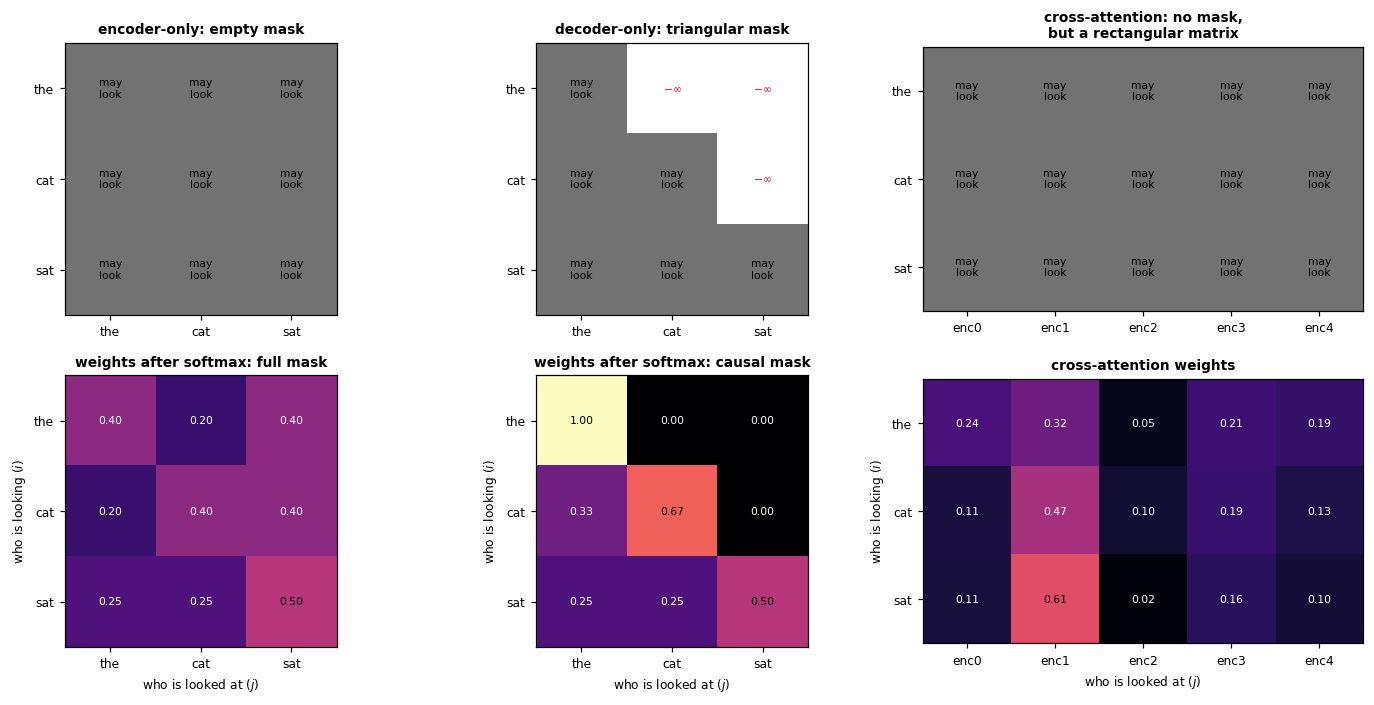

scores = QK^T / sqrt(d_k):
 [[0.707 0.    0.707]
 [0.    0.707 0.707]
 [0.707 0.707 1.414]]

row «the» with the full mask:    [0.401 0.198 0.401]  sum = 1.0
row «the» with the causal mask:  [1. 0. 0.]  sum = 1.0

states h_i = sum_j a_ij v_j
  full        [[0.802, 0.599], [0.599, 0.802], [0.752, 0.752]]
  causal      [[1.0, 0.0], [0.33, 0.67], [0.752, 0.752]]


In [18]:
# ── Three masks and one formula, on three toy tokens ─────────────────
TOY = ["the", "cat", "sat"]
X = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])   # «embeddings» of three tokens
Q = K = V = X                                         # W_Q = W_K = W_V = I, so that everything is visible by hand
d_k = X.shape[1]

scores = Q @ K.T / np.sqrt(d_k)                       # steps 1-2 from the footnote


def softmax_rows(S):
    S = S - S.max(axis=1, keepdims=True)
    E = np.exp(S)
    return E / E.sum(axis=1, keepdims=True)


M_full = np.zeros((3, 3))                             # encoder-only: no mask
M_causal = np.triu(np.full((3, 3), -np.inf), 1)       # decoder-only and decoder self-attn
A_full = softmax_rows(scores + M_full)
A_causal = softmax_rows(scores + M_causal)

# cross-attention: queries from the decoder (3 positions), keys from the encoder (5)
rng_toy = np.random.default_rng(SEED)
X_enc = rng_toy.standard_normal((5, d_k))
A_cross = softmax_rows(Q @ X_enc.T / np.sqrt(d_k))    # no mask at all

fig, axes = plt.subplots(2, 3, figsize=(13, 6.4))
panels = [
    (axes[0, 0], np.where(np.isfinite(M_full), 1.0, 0.0), "encoder-only: empty mask",
     TOY, TOY),
    (axes[0, 1], np.where(np.isfinite(M_causal), 1.0, 0.0), "decoder-only: triangular mask",
     TOY, TOY),
    (axes[0, 2], np.ones((3, 5)), "cross-attention: no mask,\nbut a rectangular matrix",
     [f"enc{j}" for j in range(5)], TOY),
]
for ax, mat, title, xt, yt in panels:
    ax.imshow(mat, cmap="Greys", vmin=0, vmax=1.6)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(xt, fontsize=8)
    ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels(yt, fontsize=8)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, "may\nlook" if mat[i, j] else r"$-\infty$",
                    ha="center", va="center", fontsize=7,
                    color="black" if mat[i, j] else "crimson")

for ax, A, title, xt in [
    (axes[1, 0], A_full, "weights after softmax: full mask", TOY),
    (axes[1, 1], A_causal, "weights after softmax: causal mask", TOY),
    (axes[1, 2], A_cross, "cross-attention weights", [f"enc{j}" for j in range(5)]),
]:
    im = ax.imshow(A, cmap="magma", vmin=0, vmax=1)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xticks(range(A.shape[1])); ax.set_xticklabels(xt, fontsize=8)
    ax.set_yticks(range(A.shape[0])); ax.set_yticklabels(TOY, fontsize=8)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            ax.text(j, i, f"{A[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="w" if A[i, j] < 0.5 else "k")
    ax.set_xlabel("who is looked at ($j$)", fontsize=8)
    ax.set_ylabel("who is looking ($i$)", fontsize=8)

plt.tight_layout()
plt.show()

print("scores = QK^T / sqrt(d_k):\n", np.round(scores, 3))
print("\nrow «the» with the full mask:   ", np.round(A_full[0], 3), " sum =", A_full[0].sum())
print("row «the» with the causal mask: ", np.round(A_causal[0], 3), " sum =", A_causal[0].sum())
print("\nstates h_i = sum_j a_ij v_j")
for name, A in (("full", A_full), ("causal", A_causal)):
    print(f"  {name:11s}", np.round(A @ V, 3).tolist())